In [165]:
import copy
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report, roc_curve, auc)
from sklearn.model_selection import KFold
import numpy as np

In [209]:
#NN model 1
#1 hidden layer, 32 nuerons
#uses full batch gradient descent to update weights
class BinaryClassificationNN(nn.Module):
    def __init__(self, input_size):
        super(BinaryClassificationNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.output(x).squeeze() 
        return x

In [201]:
#Training
def train_model(X_train, y_train, X_val, y_val, n_epochs=1000, model_num=1):
    # Ensure proper shape (N,1)
    y_train = y_train.unsqueeze(1)
    y_val = y_val.unsqueeze(1)
    
    # Model selection
    if model_num == 1:
        model = BinaryClassificationNN(X_train.shape[1])
    elif model_num == 2:
        model = BinaryClassificationNN2(X_train.shape[1])
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # For tracking metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())
            
            # Calculate accuracy
            preds = (val_outputs > 0.5).float()
            correct = (preds == y_val).float().sum()
            accuracy = correct / y_val.shape[0]
            val_accuracies.append(accuracy.item())
        
        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{n_epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {accuracy.item():.4f}')
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('BCE Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy', color='green')
    plt.title('Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model

In [171]:
def evaluate_classification(model, X_test, y_test, threshold=0.5):
    # Convert to tensors if needed
    if not isinstance(X_test, torch.Tensor):
        X_test = torch.FloatTensor(np.array(X_test))
    if not isinstance(y_test, torch.Tensor):
        y_test = torch.FloatTensor(np.array(y_test))
    
    model.eval()
    with torch.no_grad():
        # Get probabilities and predictions
        probabilities = model(X_test)
        predictions = (probabilities > threshold).float()
        
        # Convert to numpy
        y_true = y_test.numpy().flatten()
        y_pred = predictions.numpy().flatten()
        y_probs = probabilities.numpy().flatten()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_probs)
    
    print("\nClassification Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Confusion Matrix plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    
    classes = ["Negative", "Positive"]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
    # ROC Curve plot
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [217]:
def kfold_cross_validation(X, y, n_splits=5, n_epochs=100, model_num=1, threshold=0.5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    best_model = None
    best_roc_auc = 0.0  # Using ROC AUC as primary metric for model selection
    
    # Initialize metric trackers
    metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'roc_auc': []
    }
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f'\n{"="*40}')
        print(f'Fold {fold+1}/{n_splits}')
        print(f'{"="*40}')
        
        # Get fold data (already tensors)
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Train model
        model = train_model(X_train_fold, y_train_fold, X_val_fold, y_val_fold, n_epochs, model_num)
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            probs = model(X_val_fold)
            preds = (probs > threshold).float()
            
            y_true = y_val_fold.numpy().flatten()
            y_pred = preds.numpy().flatten()
            y_prob = probs.numpy().flatten()
            
            # Calculate metrics
            fold_metrics = {
                'accuracy': accuracy_score(y_true, y_pred),
                'precision': precision_score(y_true, y_pred, zero_division=0),
                'recall': recall_score(y_true, y_pred, zero_division=0),
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'roc_auc': roc_auc_score(y_true, y_prob)
            }
            
            # Update best model
            if fold_metrics['roc_auc'] > best_roc_auc:
                best_roc_auc = fold_metrics['roc_auc']
                best_model = copy.deepcopy(model)
                print(f"New best model (ROC AUC: {best_roc_auc:.4f})")
            
            # Store results
            fold_results.append({
                'fold': fold+1,
                **fold_metrics,
                'model': model
            })
            
            # Update metric trackers
            for k in metrics:
                metrics[k].append(fold_metrics[k])
            
            print("Validation Metrics:")
            for name, value in fold_metrics.items():
                print(f"{name.upper()}: {value:.4f}")
    
    # Calculate averages
    avg_metrics = {f'avg_{k}': np.mean(v) for k, v in metrics.items()}
    
    # Print summary
    print(f'\n{"="*40}')
    print("Cross-Validation Results:")
    print(f"Folds: {n_splits} | Epochs per fold: {n_epochs}")
    for metric, value in avg_metrics.items():
        print(f"{metric.replace('avg_', '').upper()}: {value:.4f}")
    print(f"Best Model ROC AUC: {best_roc_auc:.4f}")
    print(f'{"="*40}')
    
    return best_model, fold_results, avg_metrics

# Run with more appropriate parameters
print("\nRunning K-Fold Cross Validation:")
best_model, fold_results, avg_metrics = kfold_cross_validation(
    x_train, 
    y_train,
    n_splits=5,  # Reduced from 20 to 5 for more reliable estimates
    n_epochs=100,
    model_num=1
)

# Evaluate best model on test set
print("\nEvaluating Best Model on Test Set:")
best_model.eval()
with torch.no_grad():
    test_probs = best_model(x_test)
    test_preds = (test_probs > 0.5).float()
    
    test_metrics = {
        'accuracy': accuracy_score(y_test, test_preds),
        'precision': precision_score(y_test, test_preds, zero_division=0),
        'recall': recall_score(y_test, test_preds, zero_division=0),
        'f1': f1_score(y_test, test_preds, zero_division=0),
        'roc_auc': roc_auc_score(y_test, test_probs)
    }
    
    print("Test Set Metrics:")
    for name, value in test_metrics.items():
        print(f"{name.upper()}: {value:.4f}")


Running K-Fold Cross Validation:

Fold 1/5


ValueError: Using a target size (torch.Size([58374, 1, 1])) that is different to the input size (torch.Size([58374])) is deprecated. Please ensure they have the same size.

In [175]:
#Prepare data for input into model
def prepare_data(X): 
    cols_to_drop = ["gid", "visteam", "hometeam", "site", "date", "vruns", "hruns", "wteam", "lteam", "teamID"]
    X = X.drop(cols_to_drop, axis=1)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X

In [177]:
#Mapping score_diff to classification
def win_lose_mapping(Y):    
    Y = Y.tolist()
    # for i,item in enumerate(Y):
    #     t = type(item)
    #     if t != int:
    #         print("error not int")
    #         print(i, item)
    win_lose = []
    for i in range(len(Y)):
        diff = Y[i]
        if diff > 0:
            win_lose.append(1)
        elif diff < 0:
            win_lose.append(0)
        else:
            print("tie")
            win_lose.append(-1) 
    return win_lose

In [179]:
train = pd.read_csv("../CleanData/full_train.csv")
test = pd.read_csv("../CleanData/full_test.csv")

y_train = train["score_diff"]
x_train = prepare_data(train.drop("score_diff",axis=1)) #dtype nmpy array

y_test = test["score_diff"]
x_test = prepare_data(test.drop("score_diff",axis=1)) #dtype nmpy array

In [181]:
y_train = pd.Series(win_lose_mapping(y_train))
y_test = pd.Series(win_lose_mapping(y_test))

In [213]:
x_train = torch.FloatTensor(x_train)  
x_test = torch.FloatTensor(x_test)    

y_train = torch.FloatTensor(y_train) 
y_test = torch.FloatTensor(y_test)    

# K-Fold Cross Validation on Training Data
print("\nRunning K-Fold Cross Validation:")
results = kfold_cross_validation(x_train, y_train, model_num=1) #20 folds


Running K-Fold Cross Validation:

Fold 1/5


ValueError: Using a target size (torch.Size([58374, 1, 1])) that is different to the input size (torch.Size([58374])) is deprecated. Please ensure they have the same size.

Epoch 20/1000 | Train Loss: 18.5105 | Val Loss: 18.4917
Epoch 40/1000 | Train Loss: 17.8344 | Val Loss: 17.8271
Epoch 60/1000 | Train Loss: 16.9288 | Val Loss: 16.9153
Epoch 80/1000 | Train Loss: 15.9544 | Val Loss: 15.9448
Epoch 100/1000 | Train Loss: 15.0980 | Val Loss: 15.0998
Epoch 120/1000 | Train Loss: 14.4540 | Val Loss: 14.4725
Epoch 140/1000 | Train Loss: 14.0138 | Val Loss: 14.0513
Epoch 160/1000 | Train Loss: 13.7185 | Val Loss: 13.7731
Epoch 180/1000 | Train Loss: 13.5230 | Val Loss: 13.5913
Epoch 200/1000 | Train Loss: 13.3966 | Val Loss: 13.4772
Epoch 220/1000 | Train Loss: 13.3149 | Val Loss: 13.4091
Epoch 240/1000 | Train Loss: 13.2590 | Val Loss: 13.3632
Epoch 260/1000 | Train Loss: 13.2173 | Val Loss: 13.3342
Epoch 280/1000 | Train Loss: 13.1839 | Val Loss: 13.3160
Epoch 300/1000 | Train Loss: 13.1563 | Val Loss: 13.3014
Epoch 320/1000 | Train Loss: 13.1324 | Val Loss: 13.2906
Epoch 340/1000 | Train Loss: 13.1113 | Val Loss: 13.2824
Epoch 360/1000 | Train Loss: 13.092

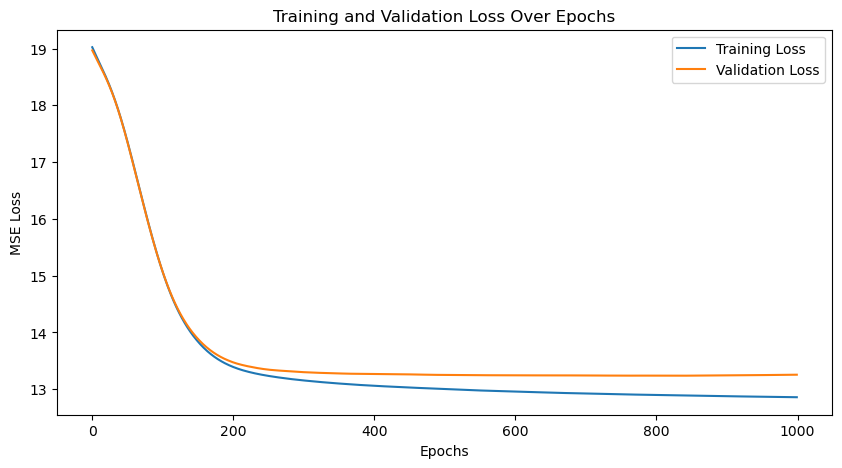


Evaluation Metrics:
MSE: 13.2562
MAE: 2.8127
R2 Score: 0.3010


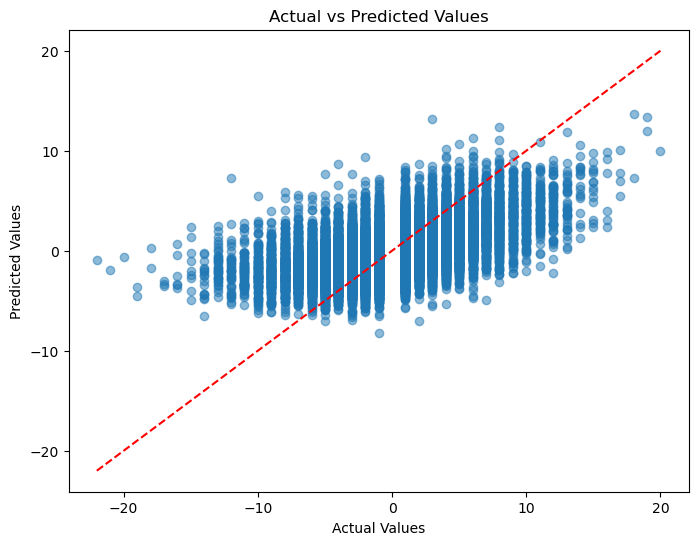

In [84]:
model = train_model(x_train, y_train, x_test, y_test, n_epochs=1000, model_num=1) 

#the model is not training on the x_test, y_test these are validation params required by the implmentatioin
#of training. The gradients are only being computed based on the x_train, y_train.

evaluate_model(model, x_test, y_test) #model is retrained with complete training dataset for evaluation.

#MAE is less sensitive to outliers
#MSE penalizes large errors more

In [64]:
#The model is good for predicting score difference but its a black box so its not as good
#at explaining the why. This is a large disadvantage for the use of sports analytics if your intent is to use it for 
#sport scouting or team building.

#only 1 hidden layer to prevent overfitting

In [163]:
#NN model 2
#2 hidden layer, 32 nuerons, 16 neurons
#uses full batch gradient descent to update weights
class BinaryClassificationNN(nn.Module):
    def __init__(self, input_size):
        super(BinaryClassificationNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))
        x = self.output(x).squeeze() 
        return x


Running K-Fold Cross Validation:

Fold 1/20
Epoch 20/1000 | Train Loss: 18.7052 | Val Loss: 18.6036
Epoch 40/1000 | Train Loss: 17.9187 | Val Loss: 17.8123
Epoch 60/1000 | Train Loss: 16.4246 | Val Loss: 16.3498
Epoch 80/1000 | Train Loss: 14.7826 | Val Loss: 14.7697
Epoch 100/1000 | Train Loss: 13.7477 | Val Loss: 13.7686
Epoch 120/1000 | Train Loss: 13.4265 | Val Loss: 13.4198
Epoch 140/1000 | Train Loss: 13.3174 | Val Loss: 13.3001
Epoch 160/1000 | Train Loss: 13.2568 | Val Loss: 13.2495
Epoch 180/1000 | Train Loss: 13.2098 | Val Loss: 13.2137
Epoch 200/1000 | Train Loss: 13.1672 | Val Loss: 13.1769
Epoch 220/1000 | Train Loss: 13.1288 | Val Loss: 13.1486
Epoch 240/1000 | Train Loss: 13.0937 | Val Loss: 13.1224
Epoch 260/1000 | Train Loss: 13.0626 | Val Loss: 13.1028
Epoch 280/1000 | Train Loss: 13.0338 | Val Loss: 13.0877
Epoch 300/1000 | Train Loss: 13.0088 | Val Loss: 13.0811
Epoch 320/1000 | Train Loss: 12.9896 | Val Loss: 13.0810
Epoch 340/1000 | Train Loss: 12.9722 | Val Loss

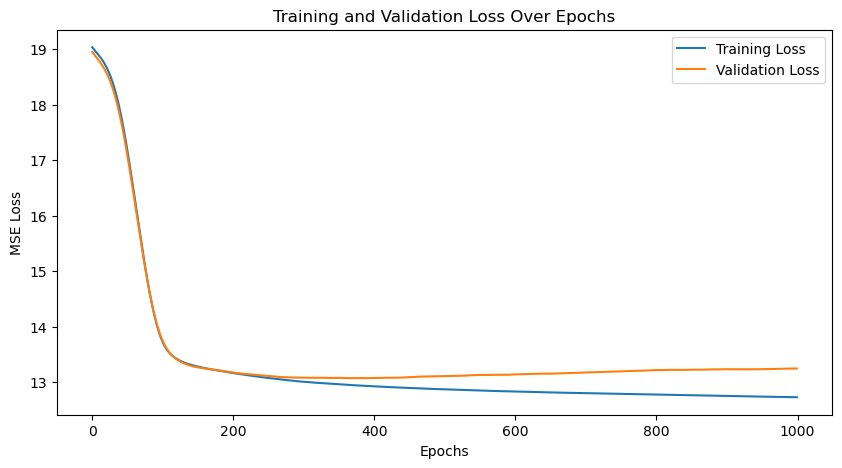

New best model found with MSE: 13.2465
Validation Metrics - MSE: 13.2465, MAE: 2.8093, R2: 0.2992

Fold 2/20
Epoch 20/1000 | Train Loss: 18.6510 | Val Loss: 18.1073
Epoch 40/1000 | Train Loss: 17.8979 | Val Loss: 17.3437
Epoch 60/1000 | Train Loss: 16.4905 | Val Loss: 15.9151
Epoch 80/1000 | Train Loss: 14.8088 | Val Loss: 14.2388
Epoch 100/1000 | Train Loss: 13.7535 | Val Loss: 13.2221
Epoch 120/1000 | Train Loss: 13.3984 | Val Loss: 12.9272
Epoch 140/1000 | Train Loss: 13.2817 | Val Loss: 12.8836
Epoch 160/1000 | Train Loss: 13.2157 | Val Loss: 12.8712
Epoch 180/1000 | Train Loss: 13.1675 | Val Loss: 12.8545
Epoch 200/1000 | Train Loss: 13.1285 | Val Loss: 12.8418
Epoch 220/1000 | Train Loss: 13.0944 | Val Loss: 12.8257
Epoch 240/1000 | Train Loss: 13.0653 | Val Loss: 12.8196
Epoch 260/1000 | Train Loss: 13.0418 | Val Loss: 12.8088
Epoch 280/1000 | Train Loss: 13.0215 | Val Loss: 12.8011
Epoch 300/1000 | Train Loss: 13.0036 | Val Loss: 12.8016
Epoch 320/1000 | Train Loss: 12.9872 | V

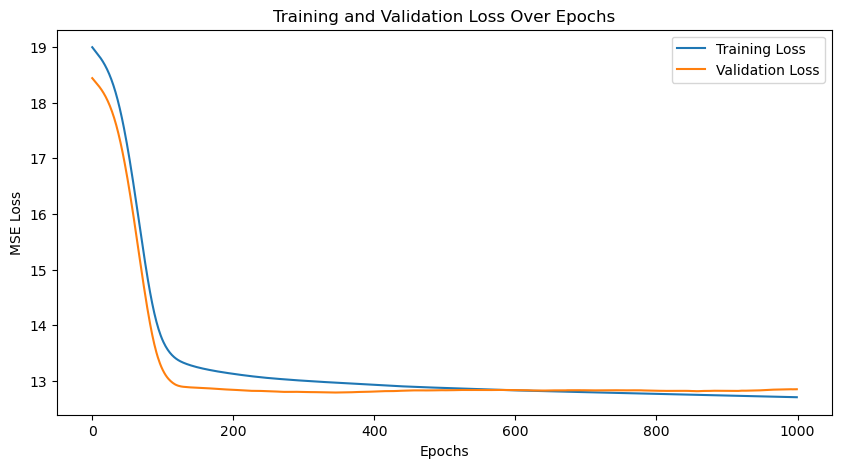

New best model found with MSE: 12.8504
Validation Metrics - MSE: 12.8504, MAE: 2.7988, R2: 0.3045

Fold 3/20
Epoch 20/1000 | Train Loss: 18.7678 | Val Loss: 18.8881
Epoch 40/1000 | Train Loss: 18.1072 | Val Loss: 18.1640
Epoch 60/1000 | Train Loss: 16.7929 | Val Loss: 16.8085
Epoch 80/1000 | Train Loss: 15.2543 | Val Loss: 15.2416
Epoch 100/1000 | Train Loss: 14.2042 | Val Loss: 14.1928
Epoch 120/1000 | Train Loss: 13.6801 | Val Loss: 13.7041
Epoch 140/1000 | Train Loss: 13.4297 | Val Loss: 13.4649
Epoch 160/1000 | Train Loss: 13.3041 | Val Loss: 13.3436
Epoch 180/1000 | Train Loss: 13.2223 | Val Loss: 13.2831
Epoch 200/1000 | Train Loss: 13.1579 | Val Loss: 13.2525
Epoch 220/1000 | Train Loss: 13.1078 | Val Loss: 13.2212
Epoch 240/1000 | Train Loss: 13.0687 | Val Loss: 13.1920
Epoch 260/1000 | Train Loss: 13.0369 | Val Loss: 13.1721
Epoch 280/1000 | Train Loss: 13.0091 | Val Loss: 13.1642
Epoch 300/1000 | Train Loss: 12.9867 | Val Loss: 13.1514
Epoch 320/1000 | Train Loss: 12.9687 | V

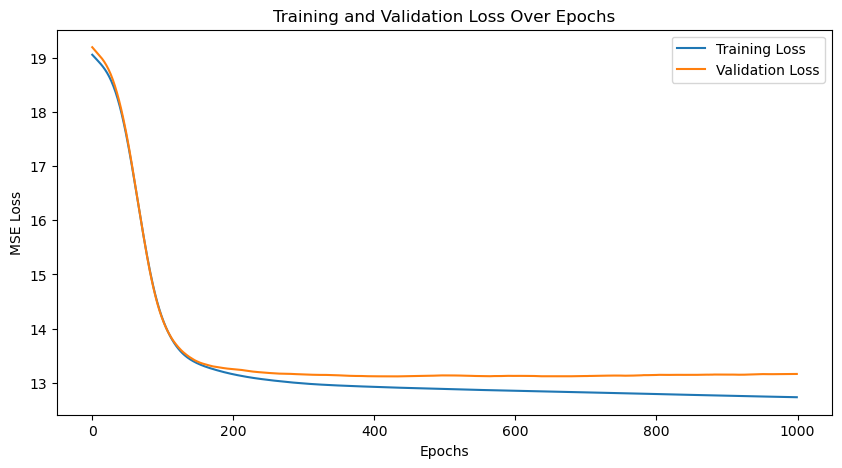

Validation Metrics - MSE: 13.1615, MAE: 2.8242, R2: 0.3098

Fold 4/20
Epoch 20/1000 | Train Loss: 18.5469 | Val Loss: 19.3388
Epoch 40/1000 | Train Loss: 17.5407 | Val Loss: 18.2769
Epoch 60/1000 | Train Loss: 15.7446 | Val Loss: 16.4768
Epoch 80/1000 | Train Loss: 14.0996 | Val Loss: 14.8874
Epoch 100/1000 | Train Loss: 13.4589 | Val Loss: 14.2751
Epoch 120/1000 | Train Loss: 13.2994 | Val Loss: 14.0963
Epoch 140/1000 | Train Loss: 13.2295 | Val Loss: 14.0537
Epoch 160/1000 | Train Loss: 13.1767 | Val Loss: 14.0327
Epoch 180/1000 | Train Loss: 13.1328 | Val Loss: 14.0059
Epoch 200/1000 | Train Loss: 13.0968 | Val Loss: 13.9852
Epoch 220/1000 | Train Loss: 13.0628 | Val Loss: 13.9624
Epoch 240/1000 | Train Loss: 13.0317 | Val Loss: 13.9530
Epoch 260/1000 | Train Loss: 13.0051 | Val Loss: 13.9335
Epoch 280/1000 | Train Loss: 12.9816 | Val Loss: 13.9189
Epoch 300/1000 | Train Loss: 12.9597 | Val Loss: 13.9070
Epoch 320/1000 | Train Loss: 12.9409 | Val Loss: 13.9048
Epoch 340/1000 | Train

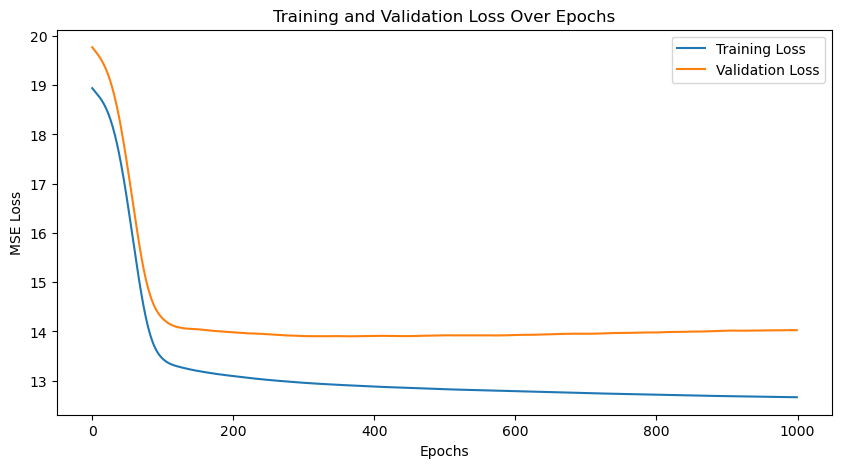

Validation Metrics - MSE: 14.0264, MAE: 2.8808, R2: 0.2911

Fold 5/20
Epoch 20/1000 | Train Loss: 18.6067 | Val Loss: 18.1558
Epoch 40/1000 | Train Loss: 17.7160 | Val Loss: 17.2976
Epoch 60/1000 | Train Loss: 16.2137 | Val Loss: 15.8417
Epoch 80/1000 | Train Loss: 14.6135 | Val Loss: 14.3218
Epoch 100/1000 | Train Loss: 13.7222 | Val Loss: 13.5312
Epoch 120/1000 | Train Loss: 13.3967 | Val Loss: 13.2744
Epoch 140/1000 | Train Loss: 13.2911 | Val Loss: 13.2009
Epoch 160/1000 | Train Loss: 13.2249 | Val Loss: 13.1619
Epoch 180/1000 | Train Loss: 13.1744 | Val Loss: 13.1536
Epoch 200/1000 | Train Loss: 13.1334 | Val Loss: 13.1473
Epoch 220/1000 | Train Loss: 13.0985 | Val Loss: 13.1407
Epoch 240/1000 | Train Loss: 13.0692 | Val Loss: 13.1346
Epoch 260/1000 | Train Loss: 13.0429 | Val Loss: 13.1400
Epoch 280/1000 | Train Loss: 13.0201 | Val Loss: 13.1477
Epoch 300/1000 | Train Loss: 12.9985 | Val Loss: 13.1508
Epoch 320/1000 | Train Loss: 12.9788 | Val Loss: 13.1511
Epoch 340/1000 | Train

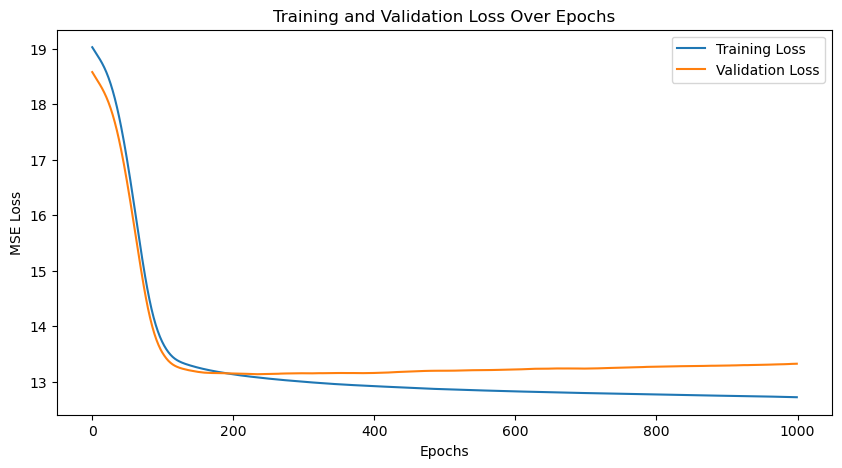

Validation Metrics - MSE: 13.3230, MAE: 2.8000, R2: 0.2811

Fold 6/20
Epoch 20/1000 | Train Loss: 18.6658 | Val Loss: 18.8689
Epoch 40/1000 | Train Loss: 17.8504 | Val Loss: 18.0372
Epoch 60/1000 | Train Loss: 16.3060 | Val Loss: 16.4631
Epoch 80/1000 | Train Loss: 14.5845 | Val Loss: 14.7385
Epoch 100/1000 | Train Loss: 13.6791 | Val Loss: 13.8805
Epoch 120/1000 | Train Loss: 13.3789 | Val Loss: 13.5995
Epoch 140/1000 | Train Loss: 13.2797 | Val Loss: 13.5289
Epoch 160/1000 | Train Loss: 13.2179 | Val Loss: 13.5036
Epoch 180/1000 | Train Loss: 13.1722 | Val Loss: 13.4781
Epoch 200/1000 | Train Loss: 13.1331 | Val Loss: 13.4511
Epoch 220/1000 | Train Loss: 13.1001 | Val Loss: 13.4335
Epoch 240/1000 | Train Loss: 13.0698 | Val Loss: 13.4191
Epoch 260/1000 | Train Loss: 13.0428 | Val Loss: 13.4036
Epoch 280/1000 | Train Loss: 13.0179 | Val Loss: 13.3953
Epoch 300/1000 | Train Loss: 12.9949 | Val Loss: 13.3863
Epoch 320/1000 | Train Loss: 12.9742 | Val Loss: 13.3797
Epoch 340/1000 | Train

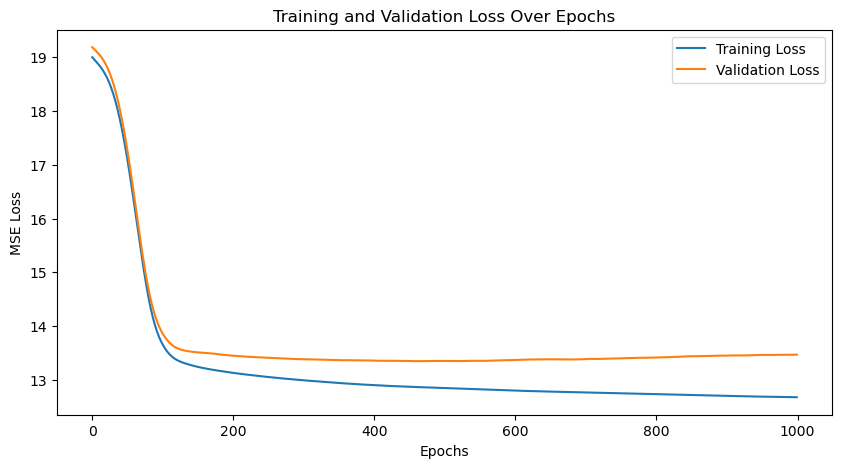

Validation Metrics - MSE: 13.4703, MAE: 2.8326, R2: 0.2975

Fold 7/20
Epoch 20/1000 | Train Loss: 18.7421 | Val Loss: 19.3441
Epoch 40/1000 | Train Loss: 18.0837 | Val Loss: 18.6258
Epoch 60/1000 | Train Loss: 16.7169 | Val Loss: 17.1581
Epoch 80/1000 | Train Loss: 14.9179 | Val Loss: 15.2473
Epoch 100/1000 | Train Loss: 13.7294 | Val Loss: 14.0329
Epoch 120/1000 | Train Loss: 13.3858 | Val Loss: 13.6835
Epoch 140/1000 | Train Loss: 13.2705 | Val Loss: 13.5732
Epoch 160/1000 | Train Loss: 13.2040 | Val Loss: 13.5344
Epoch 180/1000 | Train Loss: 13.1536 | Val Loss: 13.5001
Epoch 200/1000 | Train Loss: 13.1132 | Val Loss: 13.4726
Epoch 220/1000 | Train Loss: 13.0804 | Val Loss: 13.4595
Epoch 240/1000 | Train Loss: 13.0490 | Val Loss: 13.4487
Epoch 260/1000 | Train Loss: 13.0233 | Val Loss: 13.4386
Epoch 280/1000 | Train Loss: 13.0013 | Val Loss: 13.4320
Epoch 300/1000 | Train Loss: 12.9812 | Val Loss: 13.4289
Epoch 320/1000 | Train Loss: 12.9639 | Val Loss: 13.4176
Epoch 340/1000 | Train

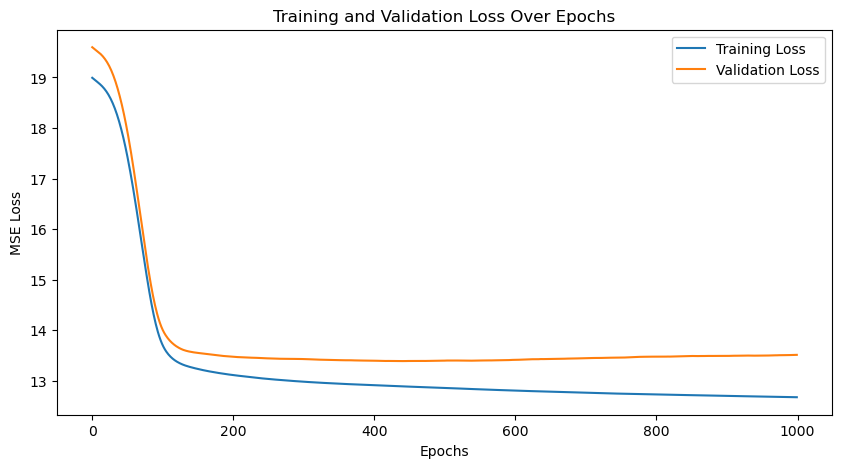

Validation Metrics - MSE: 13.5118, MAE: 2.8391, R2: 0.3097

Fold 8/20
Epoch 20/1000 | Train Loss: 18.5529 | Val Loss: 18.5308
Epoch 40/1000 | Train Loss: 17.5900 | Val Loss: 17.5735
Epoch 60/1000 | Train Loss: 15.9875 | Val Loss: 15.9890
Epoch 80/1000 | Train Loss: 14.4569 | Val Loss: 14.5553
Epoch 100/1000 | Train Loss: 13.6889 | Val Loss: 13.9621
Epoch 120/1000 | Train Loss: 13.3818 | Val Loss: 13.7847
Epoch 140/1000 | Train Loss: 13.2622 | Val Loss: 13.7385
Epoch 160/1000 | Train Loss: 13.1943 | Val Loss: 13.7045
Epoch 180/1000 | Train Loss: 13.1449 | Val Loss: 13.6906
Epoch 200/1000 | Train Loss: 13.1018 | Val Loss: 13.6726
Epoch 220/1000 | Train Loss: 13.0650 | Val Loss: 13.6576
Epoch 240/1000 | Train Loss: 13.0337 | Val Loss: 13.6548
Epoch 260/1000 | Train Loss: 13.0073 | Val Loss: 13.6545
Epoch 280/1000 | Train Loss: 12.9845 | Val Loss: 13.6485
Epoch 300/1000 | Train Loss: 12.9639 | Val Loss: 13.6458
Epoch 320/1000 | Train Loss: 12.9444 | Val Loss: 13.6412
Epoch 340/1000 | Train

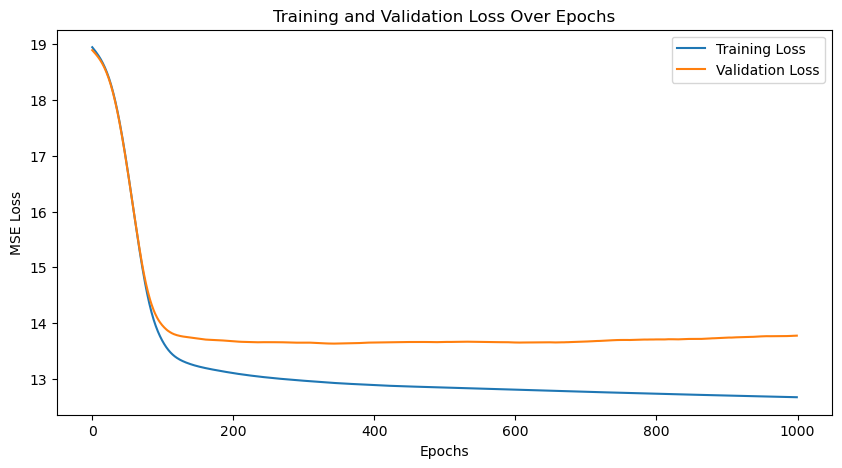

Validation Metrics - MSE: 13.7722, MAE: 2.8835, R2: 0.2738

Fold 9/20
Epoch 20/1000 | Train Loss: 18.7278 | Val Loss: 19.0841
Epoch 40/1000 | Train Loss: 18.1154 | Val Loss: 18.4721
Epoch 60/1000 | Train Loss: 16.9308 | Val Loss: 17.2879
Epoch 80/1000 | Train Loss: 15.3394 | Val Loss: 15.7683
Epoch 100/1000 | Train Loss: 14.0659 | Val Loss: 14.6117
Epoch 120/1000 | Train Loss: 13.5226 | Val Loss: 14.1169
Epoch 140/1000 | Train Loss: 13.3227 | Val Loss: 13.9516
Epoch 160/1000 | Train Loss: 13.2197 | Val Loss: 13.8909
Epoch 180/1000 | Train Loss: 13.1520 | Val Loss: 13.8686
Epoch 200/1000 | Train Loss: 13.1018 | Val Loss: 13.8443
Epoch 220/1000 | Train Loss: 13.0619 | Val Loss: 13.8210
Epoch 240/1000 | Train Loss: 13.0303 | Val Loss: 13.8091
Epoch 260/1000 | Train Loss: 13.0054 | Val Loss: 13.7955
Epoch 280/1000 | Train Loss: 12.9840 | Val Loss: 13.7892
Epoch 300/1000 | Train Loss: 12.9645 | Val Loss: 13.7889
Epoch 320/1000 | Train Loss: 12.9476 | Val Loss: 13.7807
Epoch 340/1000 | Train

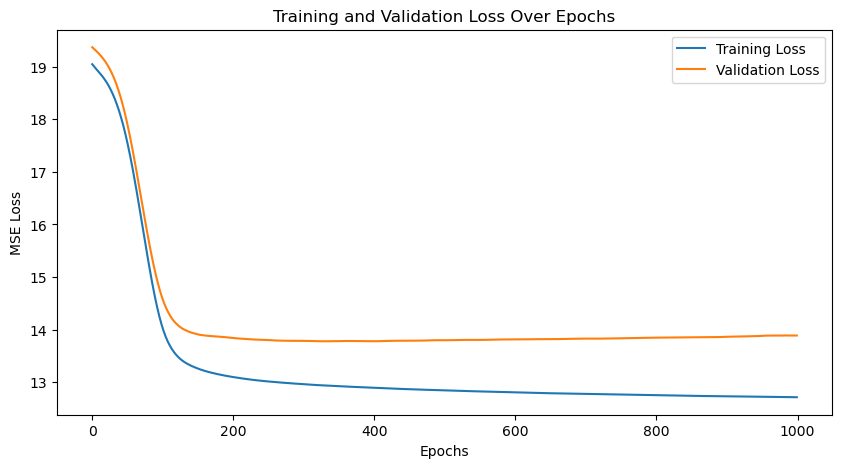

Validation Metrics - MSE: 13.8896, MAE: 2.8716, R2: 0.2823

Fold 10/20
Epoch 20/1000 | Train Loss: 18.6996 | Val Loss: 17.9075
Epoch 40/1000 | Train Loss: 17.9068 | Val Loss: 17.1155
Epoch 60/1000 | Train Loss: 16.3686 | Val Loss: 15.5870
Epoch 80/1000 | Train Loss: 14.5570 | Val Loss: 13.8645
Epoch 100/1000 | Train Loss: 13.6153 | Val Loss: 13.0874
Epoch 120/1000 | Train Loss: 13.3825 | Val Loss: 12.9503
Epoch 140/1000 | Train Loss: 13.2923 | Val Loss: 12.9182
Epoch 160/1000 | Train Loss: 13.2320 | Val Loss: 12.9016
Epoch 180/1000 | Train Loss: 13.1858 | Val Loss: 12.8984
Epoch 200/1000 | Train Loss: 13.1460 | Val Loss: 12.9030
Epoch 220/1000 | Train Loss: 13.1115 | Val Loss: 12.9017
Epoch 240/1000 | Train Loss: 13.0810 | Val Loss: 12.9019
Epoch 260/1000 | Train Loss: 13.0543 | Val Loss: 12.9026
Epoch 280/1000 | Train Loss: 13.0297 | Val Loss: 12.9030
Epoch 300/1000 | Train Loss: 13.0073 | Val Loss: 12.9070
Epoch 320/1000 | Train Loss: 12.9880 | Val Loss: 12.9047
Epoch 340/1000 | Trai

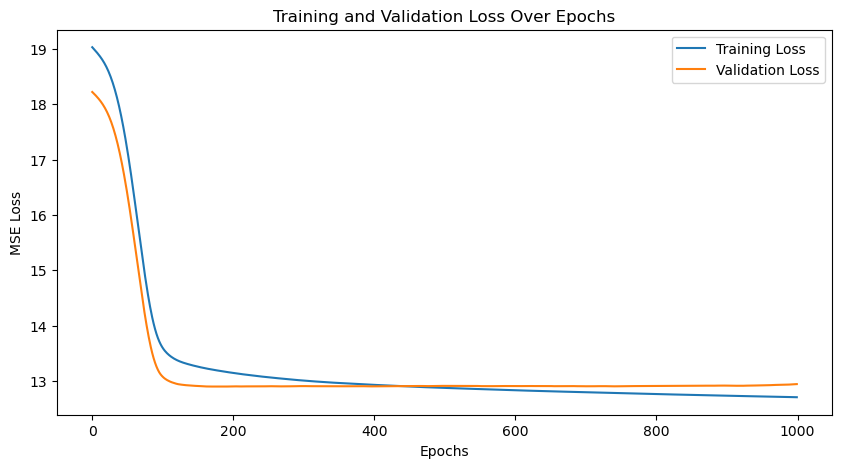

Validation Metrics - MSE: 12.9431, MAE: 2.7889, R2: 0.2906

Fold 11/20
Epoch 20/1000 | Train Loss: 18.5614 | Val Loss: 18.2044
Epoch 40/1000 | Train Loss: 17.6155 | Val Loss: 17.3387
Epoch 60/1000 | Train Loss: 16.0136 | Val Loss: 15.9110
Epoch 80/1000 | Train Loss: 14.3394 | Val Loss: 14.5453
Epoch 100/1000 | Train Loss: 13.5383 | Val Loss: 13.9865
Epoch 120/1000 | Train Loss: 13.3314 | Val Loss: 13.8513
Epoch 140/1000 | Train Loss: 13.2519 | Val Loss: 13.8011
Epoch 160/1000 | Train Loss: 13.1975 | Val Loss: 13.7855
Epoch 180/1000 | Train Loss: 13.1496 | Val Loss: 13.7796
Epoch 200/1000 | Train Loss: 13.1093 | Val Loss: 13.7694
Epoch 220/1000 | Train Loss: 13.0730 | Val Loss: 13.7710
Epoch 240/1000 | Train Loss: 13.0416 | Val Loss: 13.7799
Epoch 260/1000 | Train Loss: 13.0134 | Val Loss: 13.7743
Epoch 280/1000 | Train Loss: 12.9895 | Val Loss: 13.7742
Epoch 300/1000 | Train Loss: 12.9675 | Val Loss: 13.7780
Epoch 320/1000 | Train Loss: 12.9480 | Val Loss: 13.7914
Epoch 340/1000 | Trai

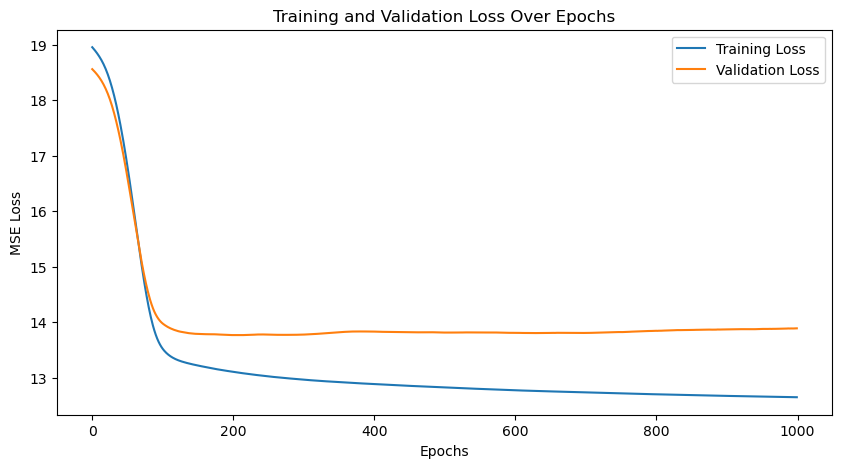

Validation Metrics - MSE: 13.8908, MAE: 2.9168, R2: 0.2544

Fold 12/20
Epoch 20/1000 | Train Loss: 18.6424 | Val Loss: 19.2512
Epoch 40/1000 | Train Loss: 17.8601 | Val Loss: 18.3950
Epoch 60/1000 | Train Loss: 16.3468 | Val Loss: 16.7113
Epoch 80/1000 | Train Loss: 14.6826 | Val Loss: 14.8779
Epoch 100/1000 | Train Loss: 13.7685 | Val Loss: 13.9204
Epoch 120/1000 | Train Loss: 13.4081 | Val Loss: 13.6292
Epoch 140/1000 | Train Loss: 13.2779 | Val Loss: 13.5527
Epoch 160/1000 | Train Loss: 13.2066 | Val Loss: 13.5112
Epoch 180/1000 | Train Loss: 13.1562 | Val Loss: 13.4895
Epoch 200/1000 | Train Loss: 13.1144 | Val Loss: 13.4728
Epoch 220/1000 | Train Loss: 13.0813 | Val Loss: 13.4589
Epoch 240/1000 | Train Loss: 13.0529 | Val Loss: 13.4381
Epoch 260/1000 | Train Loss: 13.0270 | Val Loss: 13.4277
Epoch 280/1000 | Train Loss: 13.0037 | Val Loss: 13.4172
Epoch 300/1000 | Train Loss: 12.9835 | Val Loss: 13.4053
Epoch 320/1000 | Train Loss: 12.9647 | Val Loss: 13.4037
Epoch 340/1000 | Trai

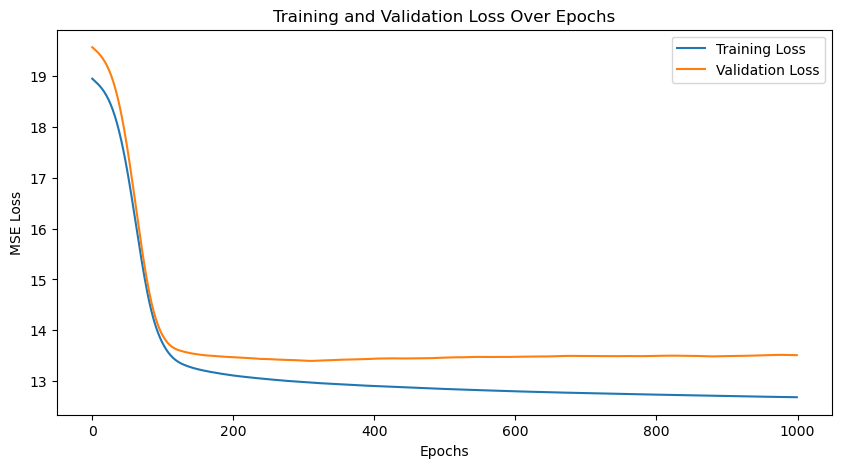

Validation Metrics - MSE: 13.5133, MAE: 2.8407, R2: 0.3102

Fold 13/20
Epoch 20/1000 | Train Loss: 18.6491 | Val Loss: 18.4632
Epoch 40/1000 | Train Loss: 17.8495 | Val Loss: 17.6773
Epoch 60/1000 | Train Loss: 16.3257 | Val Loss: 16.1781
Epoch 80/1000 | Train Loss: 14.5943 | Val Loss: 14.5166
Epoch 100/1000 | Train Loss: 13.6755 | Val Loss: 13.7175
Epoch 120/1000 | Train Loss: 13.4196 | Val Loss: 13.5416
Epoch 140/1000 | Train Loss: 13.3163 | Val Loss: 13.4882
Epoch 160/1000 | Train Loss: 13.2507 | Val Loss: 13.4480
Epoch 180/1000 | Train Loss: 13.2002 | Val Loss: 13.4163
Epoch 200/1000 | Train Loss: 13.1558 | Val Loss: 13.3846
Epoch 220/1000 | Train Loss: 13.1173 | Val Loss: 13.3470
Epoch 240/1000 | Train Loss: 13.0848 | Val Loss: 13.3238
Epoch 260/1000 | Train Loss: 13.0543 | Val Loss: 13.3162
Epoch 280/1000 | Train Loss: 13.0259 | Val Loss: 13.3165
Epoch 300/1000 | Train Loss: 13.0008 | Val Loss: 13.3146
Epoch 320/1000 | Train Loss: 12.9806 | Val Loss: 13.3121
Epoch 340/1000 | Trai

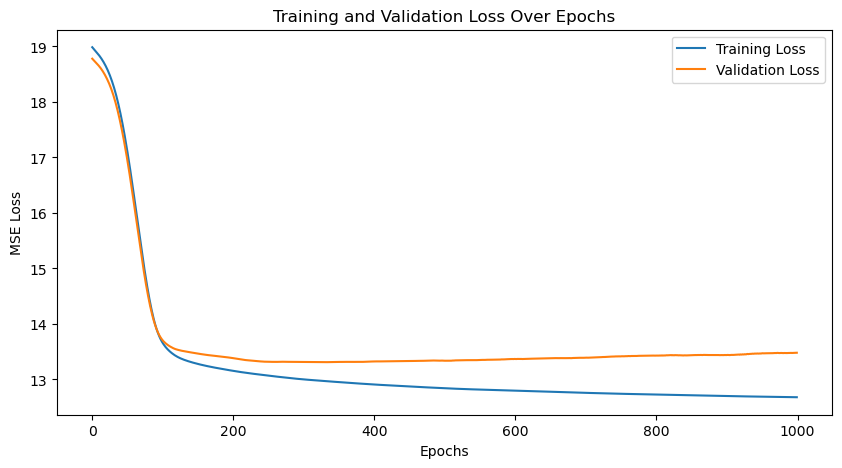

Validation Metrics - MSE: 13.4804, MAE: 2.8192, R2: 0.2829

Fold 14/20
Epoch 20/1000 | Train Loss: 18.7714 | Val Loss: 17.9634
Epoch 40/1000 | Train Loss: 18.1290 | Val Loss: 17.3358
Epoch 60/1000 | Train Loss: 16.8550 | Val Loss: 16.1025
Epoch 80/1000 | Train Loss: 15.2664 | Val Loss: 14.6419
Epoch 100/1000 | Train Loss: 14.1667 | Val Loss: 13.6816
Epoch 120/1000 | Train Loss: 13.6476 | Val Loss: 13.2123
Epoch 140/1000 | Train Loss: 13.4153 | Val Loss: 13.0152
Epoch 160/1000 | Train Loss: 13.2956 | Val Loss: 12.9571
Epoch 180/1000 | Train Loss: 13.2202 | Val Loss: 12.9376
Epoch 200/1000 | Train Loss: 13.1646 | Val Loss: 12.9296
Epoch 220/1000 | Train Loss: 13.1197 | Val Loss: 12.9372
Epoch 240/1000 | Train Loss: 13.0825 | Val Loss: 12.9380
Epoch 260/1000 | Train Loss: 13.0534 | Val Loss: 12.9446
Epoch 280/1000 | Train Loss: 13.0263 | Val Loss: 12.9480
Epoch 300/1000 | Train Loss: 13.0018 | Val Loss: 12.9489
Epoch 320/1000 | Train Loss: 12.9790 | Val Loss: 12.9489
Epoch 340/1000 | Trai

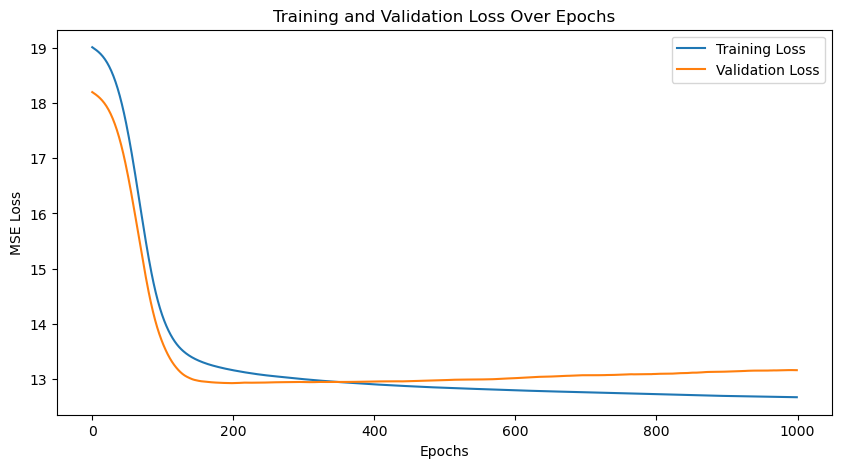

Validation Metrics - MSE: 13.1639, MAE: 2.8113, R2: 0.2771

Fold 15/20
Epoch 20/1000 | Train Loss: 18.6227 | Val Loss: 19.1886
Epoch 40/1000 | Train Loss: 17.8779 | Val Loss: 18.3968
Epoch 60/1000 | Train Loss: 16.4336 | Val Loss: 16.8677
Epoch 80/1000 | Train Loss: 14.7424 | Val Loss: 15.1039
Epoch 100/1000 | Train Loss: 13.7016 | Val Loss: 14.0163
Epoch 120/1000 | Train Loss: 13.3588 | Val Loss: 13.6626
Epoch 140/1000 | Train Loss: 13.2271 | Val Loss: 13.5455
Epoch 160/1000 | Train Loss: 13.1538 | Val Loss: 13.4901
Epoch 180/1000 | Train Loss: 13.0988 | Val Loss: 13.4613
Epoch 200/1000 | Train Loss: 13.0559 | Val Loss: 13.4492
Epoch 220/1000 | Train Loss: 13.0194 | Val Loss: 13.4429
Epoch 240/1000 | Train Loss: 12.9881 | Val Loss: 13.4415
Epoch 260/1000 | Train Loss: 12.9627 | Val Loss: 13.4379
Epoch 280/1000 | Train Loss: 12.9427 | Val Loss: 13.4379
Epoch 300/1000 | Train Loss: 12.9258 | Val Loss: 13.4353
Epoch 320/1000 | Train Loss: 12.9103 | Val Loss: 13.4390
Epoch 340/1000 | Trai

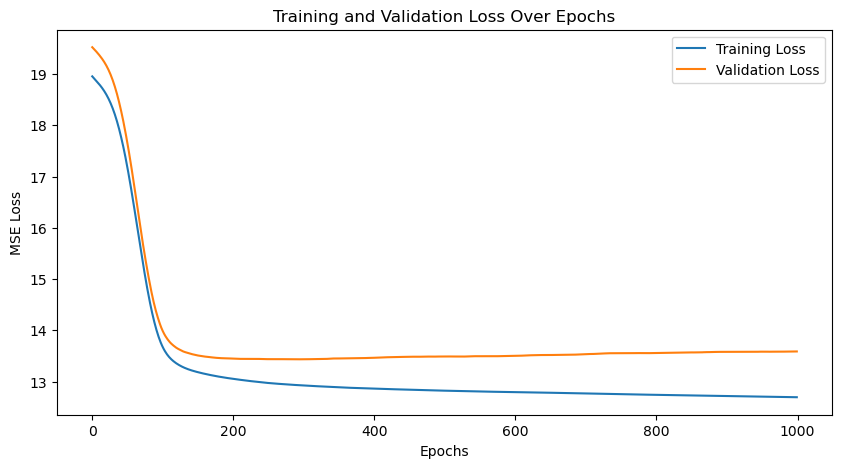

Validation Metrics - MSE: 13.5887, MAE: 2.8520, R2: 0.3052

Fold 16/20
Epoch 20/1000 | Train Loss: 18.6687 | Val Loss: 18.7525
Epoch 40/1000 | Train Loss: 17.8975 | Val Loss: 17.9702
Epoch 60/1000 | Train Loss: 16.6404 | Val Loss: 16.6856
Epoch 80/1000 | Train Loss: 15.2797 | Val Loss: 15.3480
Epoch 100/1000 | Train Loss: 14.2576 | Val Loss: 14.3847
Epoch 120/1000 | Train Loss: 13.6613 | Val Loss: 13.8663
Epoch 140/1000 | Train Loss: 13.3766 | Val Loss: 13.6579
Epoch 160/1000 | Train Loss: 13.2474 | Val Loss: 13.5800
Epoch 180/1000 | Train Loss: 13.1753 | Val Loss: 13.5487
Epoch 200/1000 | Train Loss: 13.1219 | Val Loss: 13.5281
Epoch 220/1000 | Train Loss: 13.0810 | Val Loss: 13.5182
Epoch 240/1000 | Train Loss: 13.0473 | Val Loss: 13.5068
Epoch 260/1000 | Train Loss: 13.0201 | Val Loss: 13.4971
Epoch 280/1000 | Train Loss: 12.9974 | Val Loss: 13.4978
Epoch 300/1000 | Train Loss: 12.9781 | Val Loss: 13.5038
Epoch 320/1000 | Train Loss: 12.9608 | Val Loss: 13.5057
Epoch 340/1000 | Trai

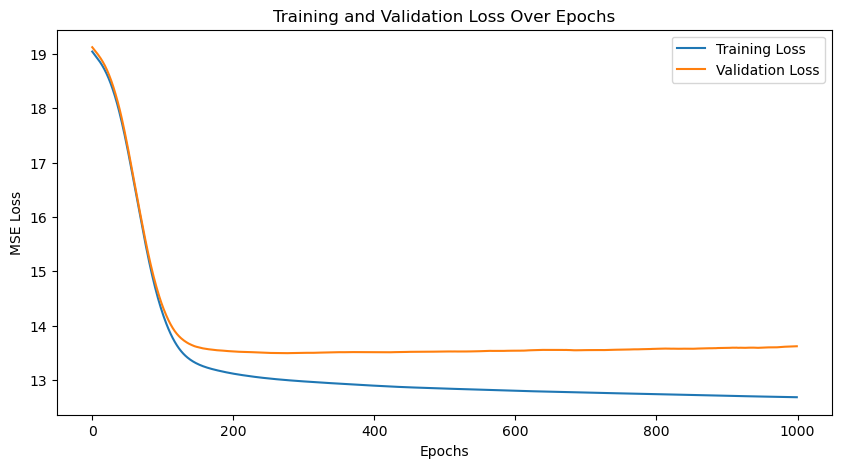

Validation Metrics - MSE: 13.6234, MAE: 2.8626, R2: 0.2855

Fold 17/20
Epoch 20/1000 | Train Loss: 18.5565 | Val Loss: 17.8276
Epoch 40/1000 | Train Loss: 17.6056 | Val Loss: 16.7982
Epoch 60/1000 | Train Loss: 16.0088 | Val Loss: 15.1001
Epoch 80/1000 | Train Loss: 14.5014 | Val Loss: 13.6001
Epoch 100/1000 | Train Loss: 13.6830 | Val Loss: 12.9281
Epoch 120/1000 | Train Loss: 13.4182 | Val Loss: 12.7990
Epoch 140/1000 | Train Loss: 13.3044 | Val Loss: 12.7357
Epoch 160/1000 | Train Loss: 13.2407 | Val Loss: 12.7083
Epoch 180/1000 | Train Loss: 13.1938 | Val Loss: 12.6952
Epoch 200/1000 | Train Loss: 13.1546 | Val Loss: 12.6777
Epoch 220/1000 | Train Loss: 13.1193 | Val Loss: 12.6713
Epoch 240/1000 | Train Loss: 13.0865 | Val Loss: 12.6715
Epoch 260/1000 | Train Loss: 13.0575 | Val Loss: 12.6691
Epoch 280/1000 | Train Loss: 13.0337 | Val Loss: 12.6588
Epoch 300/1000 | Train Loss: 13.0139 | Val Loss: 12.6531
Epoch 320/1000 | Train Loss: 12.9970 | Val Loss: 12.6522
Epoch 340/1000 | Trai

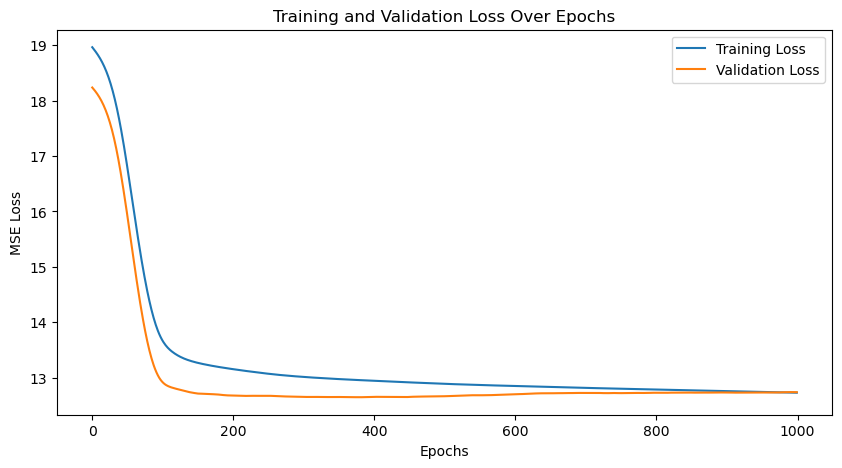

New best model found with MSE: 12.7380
Validation Metrics - MSE: 12.7380, MAE: 2.7762, R2: 0.3051

Fold 18/20
Epoch 20/1000 | Train Loss: 18.5419 | Val Loss: 18.9849
Epoch 40/1000 | Train Loss: 17.6285 | Val Loss: 17.9702
Epoch 60/1000 | Train Loss: 15.9722 | Val Loss: 16.1738
Epoch 80/1000 | Train Loss: 14.2472 | Val Loss: 14.3689
Epoch 100/1000 | Train Loss: 13.5184 | Val Loss: 13.7008
Epoch 120/1000 | Train Loss: 13.3300 | Val Loss: 13.6008
Epoch 140/1000 | Train Loss: 13.2610 | Val Loss: 13.5486
Epoch 160/1000 | Train Loss: 13.2110 | Val Loss: 13.5138
Epoch 180/1000 | Train Loss: 13.1702 | Val Loss: 13.4967
Epoch 200/1000 | Train Loss: 13.1332 | Val Loss: 13.4830
Epoch 220/1000 | Train Loss: 13.1001 | Val Loss: 13.4690
Epoch 240/1000 | Train Loss: 13.0718 | Val Loss: 13.4593
Epoch 260/1000 | Train Loss: 13.0469 | Val Loss: 13.4526
Epoch 280/1000 | Train Loss: 13.0234 | Val Loss: 13.4538
Epoch 300/1000 | Train Loss: 13.0025 | Val Loss: 13.4621
Epoch 320/1000 | Train Loss: 12.9843 | 

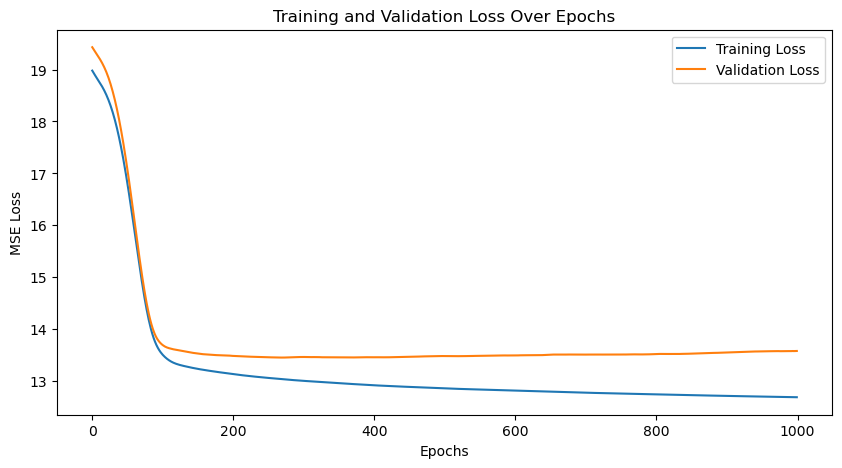

Validation Metrics - MSE: 13.5777, MAE: 2.8539, R2: 0.3013

Fold 19/20
Epoch 20/1000 | Train Loss: 18.6954 | Val Loss: 18.4504
Epoch 40/1000 | Train Loss: 17.9446 | Val Loss: 17.6990
Epoch 60/1000 | Train Loss: 16.5023 | Val Loss: 16.2779
Epoch 80/1000 | Train Loss: 14.8272 | Val Loss: 14.6971
Epoch 100/1000 | Train Loss: 13.8127 | Val Loss: 13.8057
Epoch 120/1000 | Train Loss: 13.4183 | Val Loss: 13.5547
Epoch 140/1000 | Train Loss: 13.2809 | Val Loss: 13.4880
Epoch 160/1000 | Train Loss: 13.2050 | Val Loss: 13.4374
Epoch 180/1000 | Train Loss: 13.1500 | Val Loss: 13.4093
Epoch 200/1000 | Train Loss: 13.1038 | Val Loss: 13.3940
Epoch 220/1000 | Train Loss: 13.0640 | Val Loss: 13.3852
Epoch 240/1000 | Train Loss: 13.0328 | Val Loss: 13.3812
Epoch 260/1000 | Train Loss: 13.0073 | Val Loss: 13.3878
Epoch 280/1000 | Train Loss: 12.9858 | Val Loss: 13.3945
Epoch 300/1000 | Train Loss: 12.9679 | Val Loss: 13.3973
Epoch 320/1000 | Train Loss: 12.9522 | Val Loss: 13.3899
Epoch 340/1000 | Trai

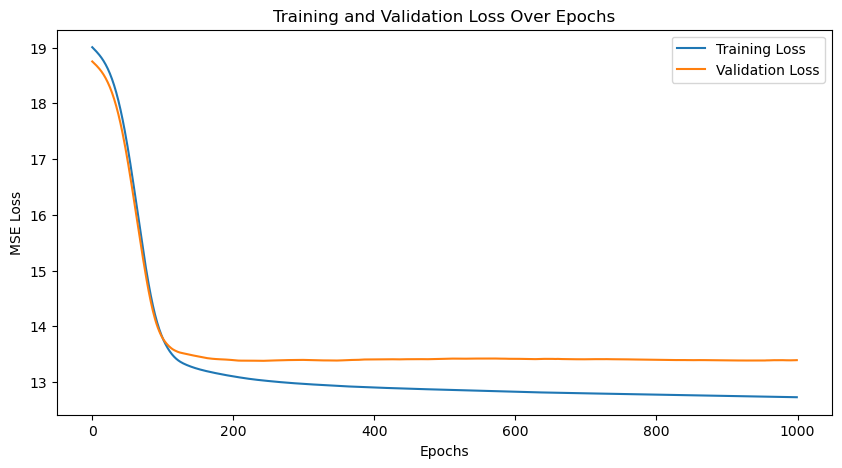

Validation Metrics - MSE: 13.3930, MAE: 2.8410, R2: 0.2856

Fold 20/20
Epoch 20/1000 | Train Loss: 18.7653 | Val Loss: 18.9071
Epoch 40/1000 | Train Loss: 18.1528 | Val Loss: 18.2575
Epoch 60/1000 | Train Loss: 16.8340 | Val Loss: 16.8619
Epoch 80/1000 | Train Loss: 15.0113 | Val Loss: 14.9354
Epoch 100/1000 | Train Loss: 13.8075 | Val Loss: 13.6668
Epoch 120/1000 | Train Loss: 13.4273 | Val Loss: 13.2452
Epoch 140/1000 | Train Loss: 13.3045 | Val Loss: 13.1482
Epoch 160/1000 | Train Loss: 13.2359 | Val Loss: 13.1100
Epoch 180/1000 | Train Loss: 13.1866 | Val Loss: 13.0901
Epoch 200/1000 | Train Loss: 13.1496 | Val Loss: 13.0671
Epoch 220/1000 | Train Loss: 13.1193 | Val Loss: 13.0414
Epoch 240/1000 | Train Loss: 13.0943 | Val Loss: 13.0234
Epoch 260/1000 | Train Loss: 13.0724 | Val Loss: 13.0127
Epoch 280/1000 | Train Loss: 13.0531 | Val Loss: 12.9997
Epoch 300/1000 | Train Loss: 13.0359 | Val Loss: 12.9848
Epoch 320/1000 | Train Loss: 13.0203 | Val Loss: 12.9804
Epoch 340/1000 | Trai

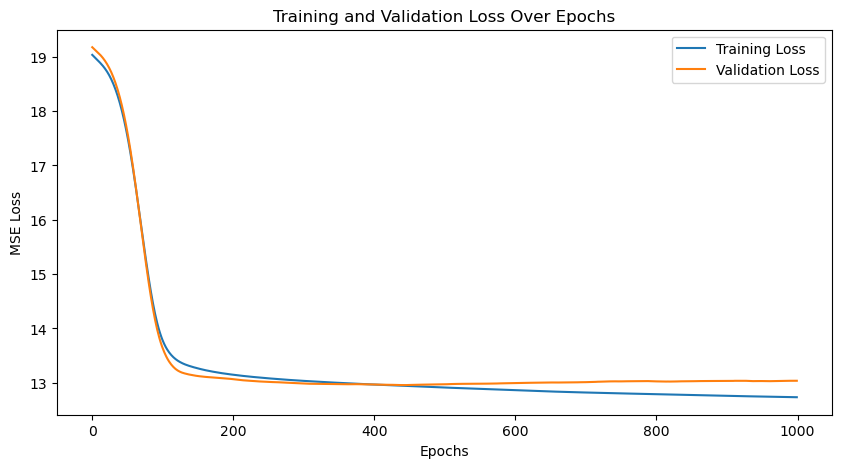

Validation Metrics - MSE: 13.0373, MAE: 2.7986, R2: 0.3199

Cross-Validation Summary:
Average MSE: 13.4101
Average MAE: 2.8350
Average R2: 0.2933
Best Model MSE: 12.7380


In [103]:
# K-Fold Cross Validation on Training Data
print("\nRunning K-Fold Cross Validation:")
results = kfold_cross_validation(x_train, y_train, model_num=2) #20 folds

Epoch 20/1000 | Train Loss: 18.7767 | Val Loss: 18.7503
Epoch 40/1000 | Train Loss: 18.1410 | Val Loss: 18.0922
Epoch 60/1000 | Train Loss: 16.6742 | Val Loss: 16.5901
Epoch 80/1000 | Train Loss: 14.7843 | Val Loss: 14.7254
Epoch 100/1000 | Train Loss: 13.7145 | Val Loss: 13.7400
Epoch 120/1000 | Train Loss: 13.3822 | Val Loss: 13.4634
Epoch 140/1000 | Train Loss: 13.2679 | Val Loss: 13.3732
Epoch 160/1000 | Train Loss: 13.2000 | Val Loss: 13.3292
Epoch 180/1000 | Train Loss: 13.1515 | Val Loss: 13.3000
Epoch 200/1000 | Train Loss: 13.1126 | Val Loss: 13.2828
Epoch 220/1000 | Train Loss: 13.0783 | Val Loss: 13.2705
Epoch 240/1000 | Train Loss: 13.0493 | Val Loss: 13.2620
Epoch 260/1000 | Train Loss: 13.0234 | Val Loss: 13.2521
Epoch 280/1000 | Train Loss: 13.0006 | Val Loss: 13.2455
Epoch 300/1000 | Train Loss: 12.9807 | Val Loss: 13.2439
Epoch 320/1000 | Train Loss: 12.9622 | Val Loss: 13.2414
Epoch 340/1000 | Train Loss: 12.9463 | Val Loss: 13.2414
Epoch 360/1000 | Train Loss: 12.933

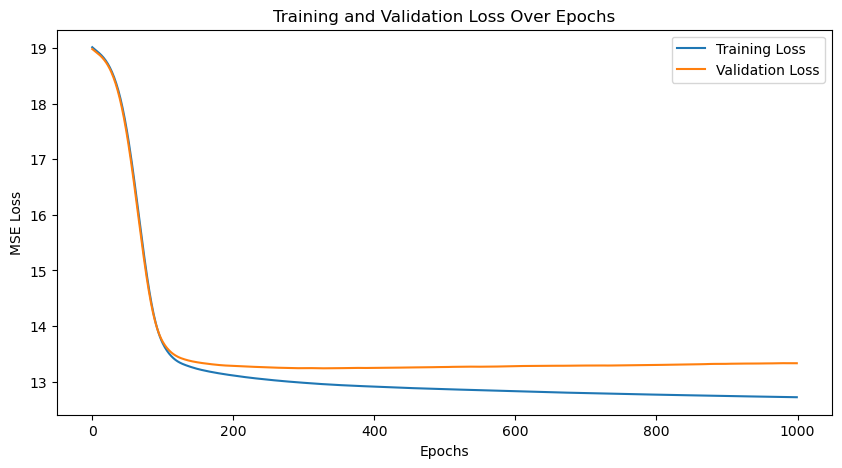


Evaluation Metrics:
MSE: 13.3315
MAE: 2.8209
R2 Score: 0.2970


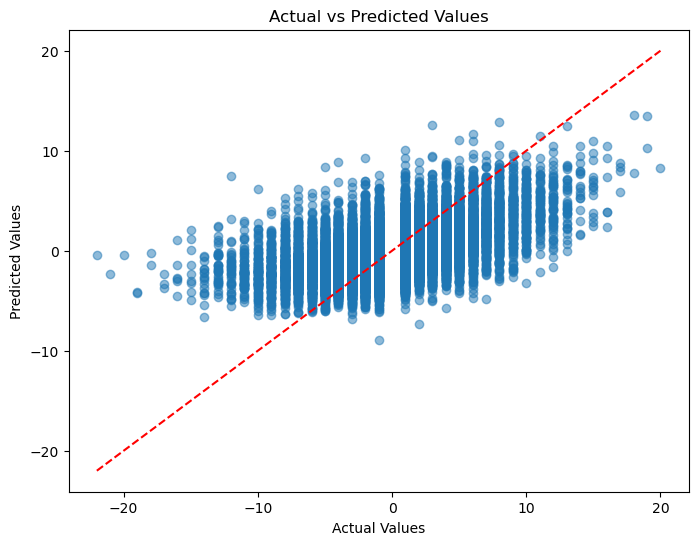

In [105]:
#Model 2 eval
model = train_model(x_train, y_train, x_test, y_test, n_epochs=1000, model_num=2) 

evaluate_model(model, x_test, y_test) #model is retrained with complete training dataset for evaluation.


In [ ]:
#No significant improvement in MSE or MAE when an additional hidden layer was added
#Elbow of validation curve appears to be around 200 epochs, then model tends to overfit


Running K-Fold Cross Validation:

Fold 1/20
Epoch 20/300 | Train Loss: 18.5630 | Val Loss: 18.5092
Epoch 40/300 | Train Loss: 17.9311 | Val Loss: 17.8773
Epoch 60/300 | Train Loss: 17.0657 | Val Loss: 17.0273
Epoch 80/300 | Train Loss: 16.0885 | Val Loss: 16.0745
Epoch 100/300 | Train Loss: 15.1891 | Val Loss: 15.2036
Epoch 120/300 | Train Loss: 14.4861 | Val Loss: 14.5151
Epoch 140/300 | Train Loss: 14.0035 | Val Loss: 14.0292
Epoch 160/300 | Train Loss: 13.6930 | Val Loss: 13.7061
Epoch 180/300 | Train Loss: 13.4959 | Val Loss: 13.5003
Epoch 200/300 | Train Loss: 13.3771 | Val Loss: 13.3749
Epoch 220/300 | Train Loss: 13.3037 | Val Loss: 13.2890
Epoch 240/300 | Train Loss: 13.2498 | Val Loss: 13.2372
Epoch 260/300 | Train Loss: 13.2086 | Val Loss: 13.2061
Epoch 280/300 | Train Loss: 13.1745 | Val Loss: 13.1797
Epoch 300/300 | Train Loss: 13.1470 | Val Loss: 13.1618


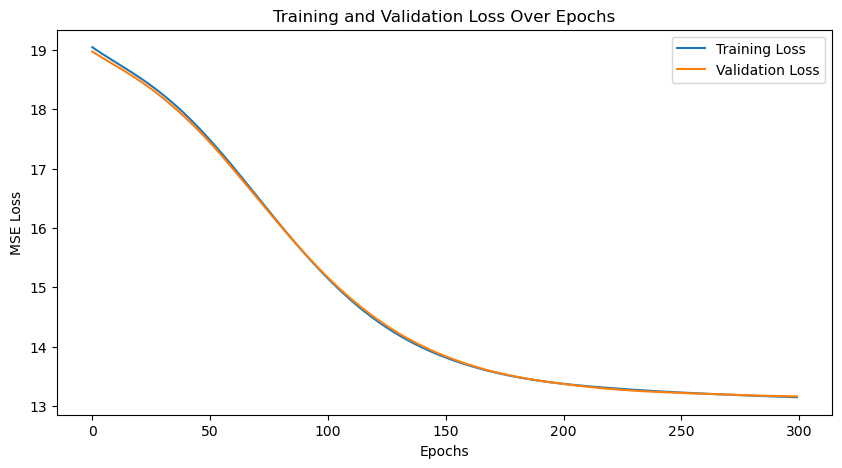

New best model found with MSE: 13.1618
Validation Metrics - MSE: 13.1618, MAE: 2.8006, R2: 0.3037

Fold 2/20
Epoch 20/300 | Train Loss: 18.5179 | Val Loss: 17.9971
Epoch 40/300 | Train Loss: 17.8197 | Val Loss: 17.3104
Epoch 60/300 | Train Loss: 16.9419 | Val Loss: 16.4202
Epoch 80/300 | Train Loss: 15.9841 | Val Loss: 15.4560
Epoch 100/300 | Train Loss: 15.1084 | Val Loss: 14.5799
Epoch 120/300 | Train Loss: 14.4386 | Val Loss: 13.9283
Epoch 140/300 | Train Loss: 14.0037 | Val Loss: 13.5189
Epoch 160/300 | Train Loss: 13.7350 | Val Loss: 13.2765
Epoch 180/300 | Train Loss: 13.5629 | Val Loss: 13.1232
Epoch 200/300 | Train Loss: 13.4510 | Val Loss: 13.0244
Epoch 220/300 | Train Loss: 13.3762 | Val Loss: 12.9640
Epoch 240/300 | Train Loss: 13.3209 | Val Loss: 12.9322
Epoch 260/300 | Train Loss: 13.2776 | Val Loss: 12.9025
Epoch 280/300 | Train Loss: 13.2420 | Val Loss: 12.8787
Epoch 300/300 | Train Loss: 13.2117 | Val Loss: 12.8618


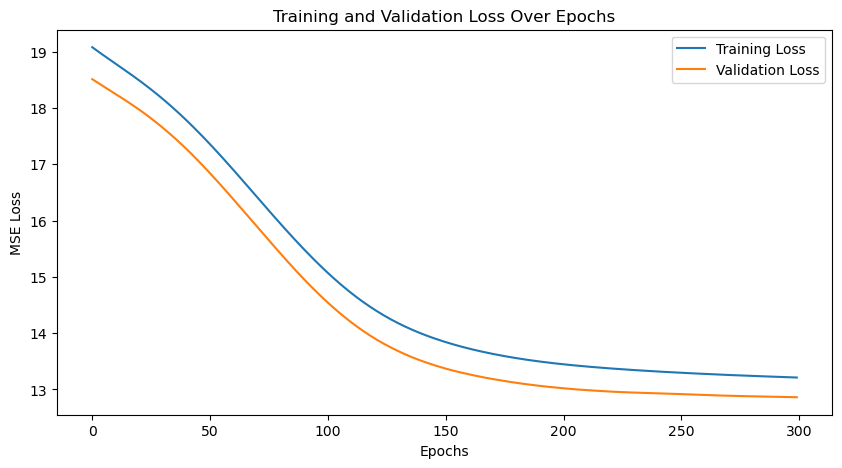

New best model found with MSE: 12.8618
Validation Metrics - MSE: 12.8618, MAE: 2.7964, R2: 0.3039

Fold 3/20
Epoch 20/300 | Train Loss: 18.7365 | Val Loss: 18.8377
Epoch 40/300 | Train Loss: 18.1925 | Val Loss: 18.3043
Epoch 60/300 | Train Loss: 17.4521 | Val Loss: 17.5714
Epoch 80/300 | Train Loss: 16.5443 | Val Loss: 16.6652
Epoch 100/300 | Train Loss: 15.6187 | Val Loss: 15.7489
Epoch 120/300 | Train Loss: 14.8130 | Val Loss: 14.9364
Epoch 140/300 | Train Loss: 14.2151 | Val Loss: 14.3264
Epoch 160/300 | Train Loss: 13.8223 | Val Loss: 13.9242
Epoch 180/300 | Train Loss: 13.5727 | Val Loss: 13.6684
Epoch 200/300 | Train Loss: 13.4176 | Val Loss: 13.5116
Epoch 220/300 | Train Loss: 13.3222 | Val Loss: 13.4190
Epoch 240/300 | Train Loss: 13.2596 | Val Loss: 13.3602
Epoch 260/300 | Train Loss: 13.2148 | Val Loss: 13.3249
Epoch 280/300 | Train Loss: 13.1799 | Val Loss: 13.2980
Epoch 300/300 | Train Loss: 13.1513 | Val Loss: 13.2756


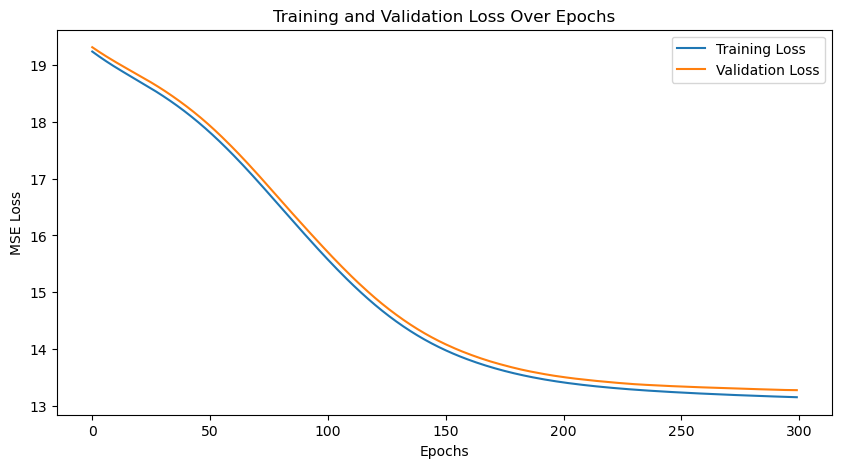

Validation Metrics - MSE: 13.2756, MAE: 2.8336, R2: 0.3038

Fold 4/20
Epoch 20/300 | Train Loss: 18.5727 | Val Loss: 19.3917
Epoch 40/300 | Train Loss: 17.9331 | Val Loss: 18.7481
Epoch 60/300 | Train Loss: 17.1056 | Val Loss: 17.9378
Epoch 80/300 | Train Loss: 16.1635 | Val Loss: 17.0214
Epoch 100/300 | Train Loss: 15.2687 | Val Loss: 16.1571
Epoch 120/300 | Train Loss: 14.5351 | Val Loss: 15.4509
Epoch 140/300 | Train Loss: 14.0183 | Val Loss: 14.9480
Epoch 160/300 | Train Loss: 13.6872 | Val Loss: 14.6121
Epoch 180/300 | Train Loss: 13.4796 | Val Loss: 14.3912
Epoch 200/300 | Train Loss: 13.3514 | Val Loss: 14.2563
Epoch 220/300 | Train Loss: 13.2720 | Val Loss: 14.1765
Epoch 240/300 | Train Loss: 13.2188 | Val Loss: 14.1249
Epoch 260/300 | Train Loss: 13.1810 | Val Loss: 14.0872
Epoch 280/300 | Train Loss: 13.1516 | Val Loss: 14.0550
Epoch 300/300 | Train Loss: 13.1259 | Val Loss: 14.0292


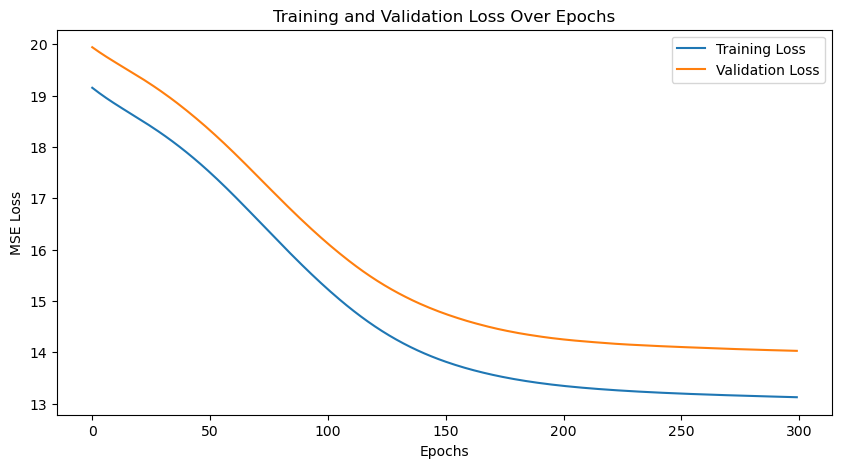

Validation Metrics - MSE: 14.0292, MAE: 2.8878, R2: 0.2910

Fold 5/20
Epoch 20/300 | Train Loss: 18.5218 | Val Loss: 18.0594
Epoch 40/300 | Train Loss: 17.8930 | Val Loss: 17.4800
Epoch 60/300 | Train Loss: 17.0491 | Val Loss: 16.6769
Epoch 80/300 | Train Loss: 16.0743 | Val Loss: 15.7584
Epoch 100/300 | Train Loss: 15.1569 | Val Loss: 14.8970
Epoch 120/300 | Train Loss: 14.4406 | Val Loss: 14.2284
Epoch 140/300 | Train Loss: 13.9600 | Val Loss: 13.7892
Epoch 160/300 | Train Loss: 13.6600 | Val Loss: 13.5282
Epoch 180/300 | Train Loss: 13.4767 | Val Loss: 13.3787
Epoch 200/300 | Train Loss: 13.3679 | Val Loss: 13.3041
Epoch 220/300 | Train Loss: 13.3021 | Val Loss: 13.2696
Epoch 240/300 | Train Loss: 13.2574 | Val Loss: 13.2568
Epoch 260/300 | Train Loss: 13.2234 | Val Loss: 13.2483
Epoch 280/300 | Train Loss: 13.1950 | Val Loss: 13.2390
Epoch 300/300 | Train Loss: 13.1704 | Val Loss: 13.2307


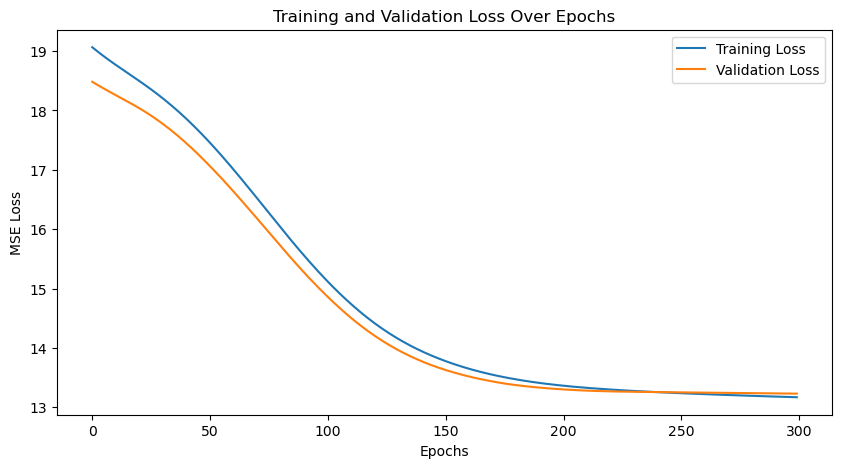

Validation Metrics - MSE: 13.2307, MAE: 2.7943, R2: 0.2861

Fold 6/20
Epoch 20/300 | Train Loss: 18.4996 | Val Loss: 18.6931
Epoch 40/300 | Train Loss: 17.8515 | Val Loss: 18.0491
Epoch 60/300 | Train Loss: 16.9947 | Val Loss: 17.1817
Epoch 80/300 | Train Loss: 16.0328 | Val Loss: 16.2167
Epoch 100/300 | Train Loss: 15.1493 | Val Loss: 15.3426
Epoch 120/300 | Train Loss: 14.4579 | Val Loss: 14.6605
Epoch 140/300 | Train Loss: 13.9852 | Val Loss: 14.1932
Epoch 160/300 | Train Loss: 13.6802 | Val Loss: 13.8901
Epoch 180/300 | Train Loss: 13.4881 | Val Loss: 13.7019
Epoch 200/300 | Train Loss: 13.3714 | Val Loss: 13.5910
Epoch 220/300 | Train Loss: 13.2954 | Val Loss: 13.5255
Epoch 240/300 | Train Loss: 13.2416 | Val Loss: 13.4803
Epoch 260/300 | Train Loss: 13.2002 | Val Loss: 13.4469
Epoch 280/300 | Train Loss: 13.1661 | Val Loss: 13.4277
Epoch 300/300 | Train Loss: 13.1370 | Val Loss: 13.4183


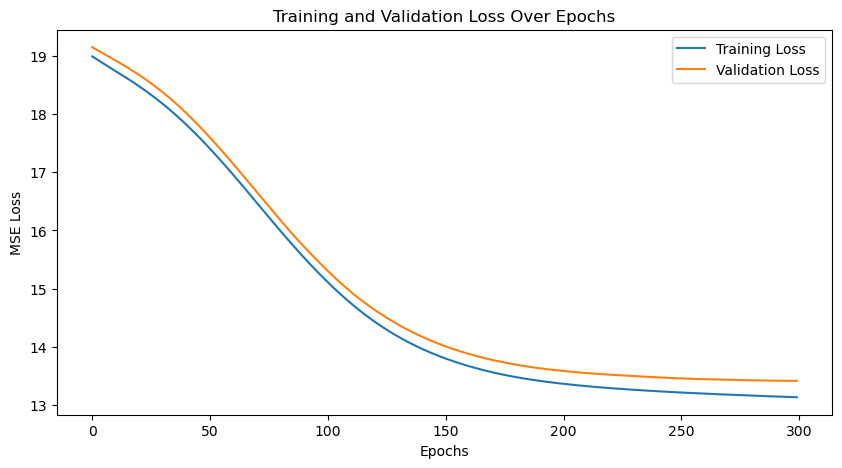

Validation Metrics - MSE: 13.4183, MAE: 2.8298, R2: 0.3002

Fold 7/20
Epoch 20/300 | Train Loss: 18.2694 | Val Loss: 18.8275
Epoch 40/300 | Train Loss: 17.5294 | Val Loss: 18.0448
Epoch 60/300 | Train Loss: 16.6293 | Val Loss: 17.0981
Epoch 80/300 | Train Loss: 15.6917 | Val Loss: 16.1180
Epoch 100/300 | Train Loss: 14.8565 | Val Loss: 15.2562
Epoch 120/300 | Train Loss: 14.2296 | Val Loss: 14.6120
Epoch 140/300 | Train Loss: 13.8233 | Val Loss: 14.1919
Epoch 160/300 | Train Loss: 13.5776 | Val Loss: 13.9347
Epoch 180/300 | Train Loss: 13.4258 | Val Loss: 13.7719
Epoch 200/300 | Train Loss: 13.3296 | Val Loss: 13.6627
Epoch 220/300 | Train Loss: 13.2648 | Val Loss: 13.5921
Epoch 240/300 | Train Loss: 13.2181 | Val Loss: 13.5482
Epoch 260/300 | Train Loss: 13.1822 | Val Loss: 13.5173
Epoch 280/300 | Train Loss: 13.1515 | Val Loss: 13.4919
Epoch 300/300 | Train Loss: 13.1247 | Val Loss: 13.4748


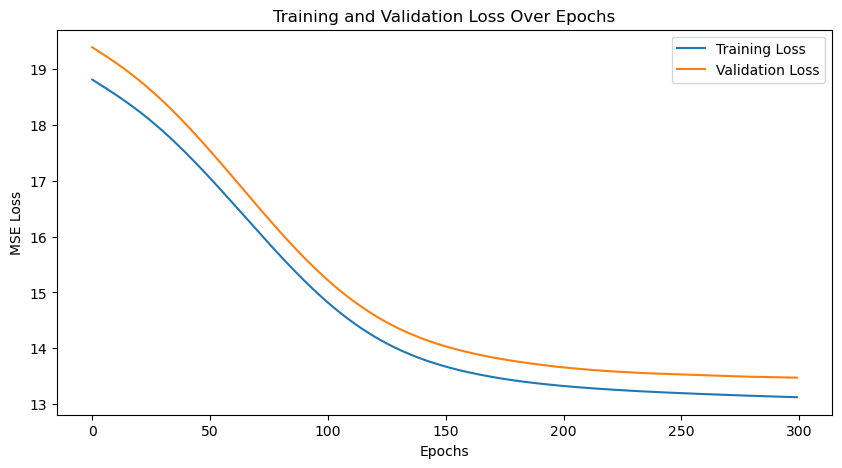

Validation Metrics - MSE: 13.4748, MAE: 2.8308, R2: 0.3116

Fold 8/20
Epoch 20/300 | Train Loss: 18.5943 | Val Loss: 18.5587
Epoch 40/300 | Train Loss: 17.9762 | Val Loss: 17.9603
Epoch 60/300 | Train Loss: 17.1057 | Val Loss: 17.1107
Epoch 80/300 | Train Loss: 16.0986 | Val Loss: 16.1397
Epoch 100/300 | Train Loss: 15.1869 | Val Loss: 15.2873
Epoch 120/300 | Train Loss: 14.4935 | Val Loss: 14.6708
Epoch 140/300 | Train Loss: 14.0078 | Val Loss: 14.2645
Epoch 160/300 | Train Loss: 13.6775 | Val Loss: 14.0017
Epoch 180/300 | Train Loss: 13.4667 | Val Loss: 13.8483
Epoch 200/300 | Train Loss: 13.3431 | Val Loss: 13.7716
Epoch 220/300 | Train Loss: 13.2699 | Val Loss: 13.7387
Epoch 240/300 | Train Loss: 13.2221 | Val Loss: 13.7258
Epoch 260/300 | Train Loss: 13.1857 | Val Loss: 13.7179
Epoch 280/300 | Train Loss: 13.1554 | Val Loss: 13.7043
Epoch 300/300 | Train Loss: 13.1277 | Val Loss: 13.6865


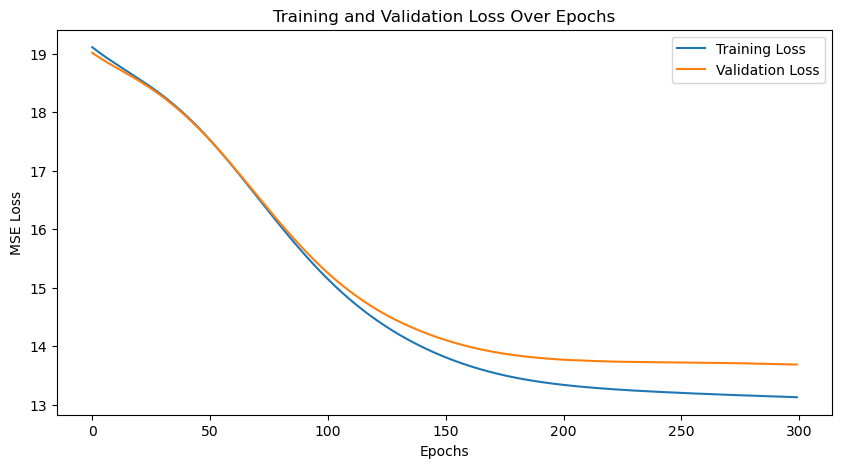

Validation Metrics - MSE: 13.6865, MAE: 2.8684, R2: 0.2783

Fold 9/20
Epoch 20/300 | Train Loss: 18.4091 | Val Loss: 18.7905
Epoch 40/300 | Train Loss: 17.6984 | Val Loss: 18.1063
Epoch 60/300 | Train Loss: 16.8304 | Val Loss: 17.2603
Epoch 80/300 | Train Loss: 15.9140 | Val Loss: 16.3908
Epoch 100/300 | Train Loss: 15.0879 | Val Loss: 15.6194
Epoch 120/300 | Train Loss: 14.4463 | Val Loss: 15.0297
Epoch 140/300 | Train Loss: 14.0076 | Val Loss: 14.6238
Epoch 160/300 | Train Loss: 13.7230 | Val Loss: 14.3500
Epoch 180/300 | Train Loss: 13.5333 | Val Loss: 14.1659
Epoch 200/300 | Train Loss: 13.4085 | Val Loss: 14.0485
Epoch 220/300 | Train Loss: 13.3264 | Val Loss: 13.9773
Epoch 240/300 | Train Loss: 13.2688 | Val Loss: 13.9296
Epoch 260/300 | Train Loss: 13.2259 | Val Loss: 13.8917
Epoch 280/300 | Train Loss: 13.1912 | Val Loss: 13.8628
Epoch 300/300 | Train Loss: 13.1622 | Val Loss: 13.8408


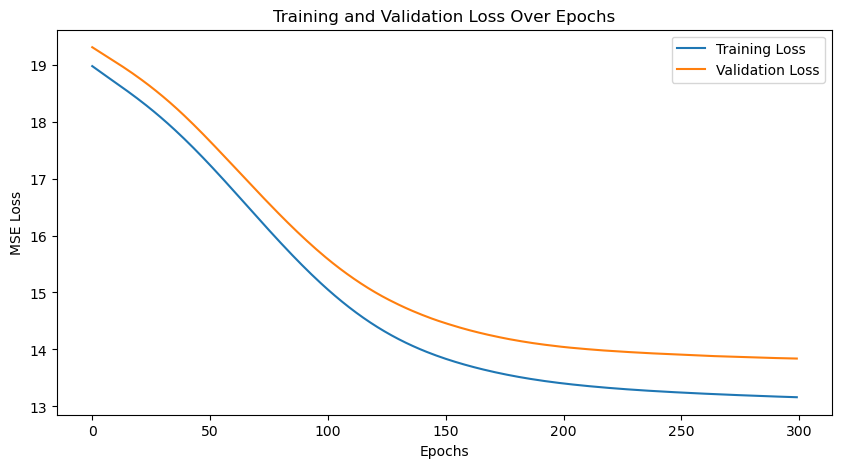

Validation Metrics - MSE: 13.8408, MAE: 2.8717, R2: 0.2848

Fold 10/20
Epoch 20/300 | Train Loss: 18.6271 | Val Loss: 17.8645
Epoch 40/300 | Train Loss: 17.9722 | Val Loss: 17.2345
Epoch 60/300 | Train Loss: 17.0859 | Val Loss: 16.3713
Epoch 80/300 | Train Loss: 16.0897 | Val Loss: 15.4117
Epoch 100/300 | Train Loss: 15.1809 | Val Loss: 14.5427
Epoch 120/300 | Train Loss: 14.4804 | Val Loss: 13.8876
Epoch 140/300 | Train Loss: 14.0072 | Val Loss: 13.4525
Epoch 160/300 | Train Loss: 13.7032 | Val Loss: 13.1851
Epoch 180/300 | Train Loss: 13.5083 | Val Loss: 13.0250
Epoch 200/300 | Train Loss: 13.3867 | Val Loss: 12.9372
Epoch 220/300 | Train Loss: 13.3095 | Val Loss: 12.8921
Epoch 240/300 | Train Loss: 13.2578 | Val Loss: 12.8677
Epoch 260/300 | Train Loss: 13.2201 | Val Loss: 12.8510
Epoch 280/300 | Train Loss: 13.1898 | Val Loss: 12.8442
Epoch 300/300 | Train Loss: 13.1645 | Val Loss: 12.8373


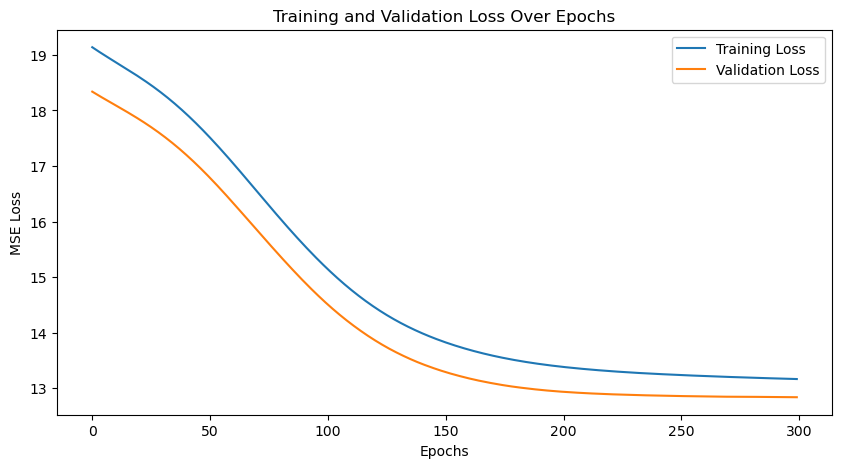

New best model found with MSE: 12.8373
Validation Metrics - MSE: 12.8373, MAE: 2.7867, R2: 0.2964

Fold 11/20
Epoch 20/300 | Train Loss: 18.4022 | Val Loss: 18.0884
Epoch 40/300 | Train Loss: 17.6904 | Val Loss: 17.4642
Epoch 60/300 | Train Loss: 16.7992 | Val Loss: 16.6675
Epoch 80/300 | Train Loss: 15.8221 | Val Loss: 15.8153
Epoch 100/300 | Train Loss: 14.9188 | Val Loss: 15.0545
Epoch 120/300 | Train Loss: 14.2330 | Val Loss: 14.5009
Epoch 140/300 | Train Loss: 13.8032 | Val Loss: 14.1682
Epoch 160/300 | Train Loss: 13.5527 | Val Loss: 13.9857
Epoch 180/300 | Train Loss: 13.4024 | Val Loss: 13.8829
Epoch 200/300 | Train Loss: 13.3088 | Val Loss: 13.8232
Epoch 220/300 | Train Loss: 13.2467 | Val Loss: 13.7889
Epoch 240/300 | Train Loss: 13.2011 | Val Loss: 13.7600
Epoch 260/300 | Train Loss: 13.1657 | Val Loss: 13.7407
Epoch 280/300 | Train Loss: 13.1358 | Val Loss: 13.7325
Epoch 300/300 | Train Loss: 13.1092 | Val Loss: 13.7271


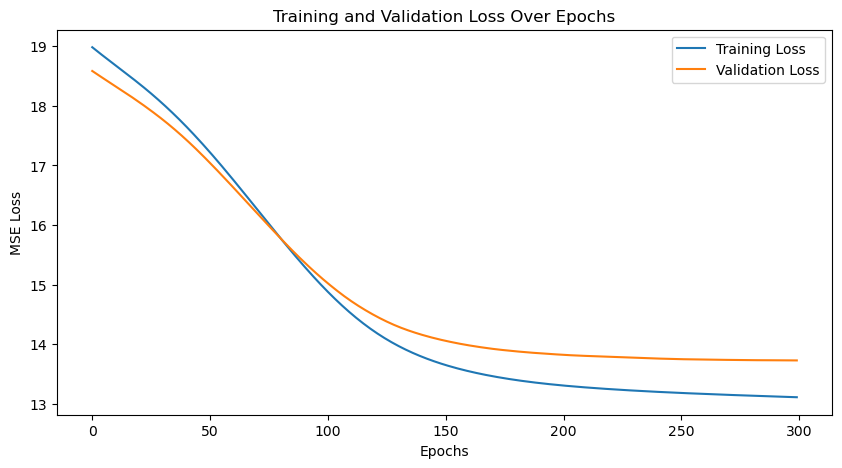

Validation Metrics - MSE: 13.7271, MAE: 2.8944, R2: 0.2632

Fold 12/20
Epoch 20/300 | Train Loss: 18.5234 | Val Loss: 19.1282
Epoch 40/300 | Train Loss: 17.8964 | Val Loss: 18.4537
Epoch 60/300 | Train Loss: 17.0273 | Val Loss: 17.5050
Epoch 80/300 | Train Loss: 16.0340 | Val Loss: 16.4218
Epoch 100/300 | Train Loss: 15.1106 | Val Loss: 15.4246
Epoch 120/300 | Train Loss: 14.4062 | Val Loss: 14.6784
Epoch 140/300 | Train Loss: 13.9405 | Val Loss: 14.1933
Epoch 160/300 | Train Loss: 13.6494 | Val Loss: 13.8962
Epoch 180/300 | Train Loss: 13.4691 | Val Loss: 13.7265
Epoch 200/300 | Train Loss: 13.3587 | Val Loss: 13.6282
Epoch 220/300 | Train Loss: 13.2879 | Val Loss: 13.5729
Epoch 240/300 | Train Loss: 13.2400 | Val Loss: 13.5379
Epoch 260/300 | Train Loss: 13.2035 | Val Loss: 13.5113
Epoch 280/300 | Train Loss: 13.1728 | Val Loss: 13.4928
Epoch 300/300 | Train Loss: 13.1457 | Val Loss: 13.4803


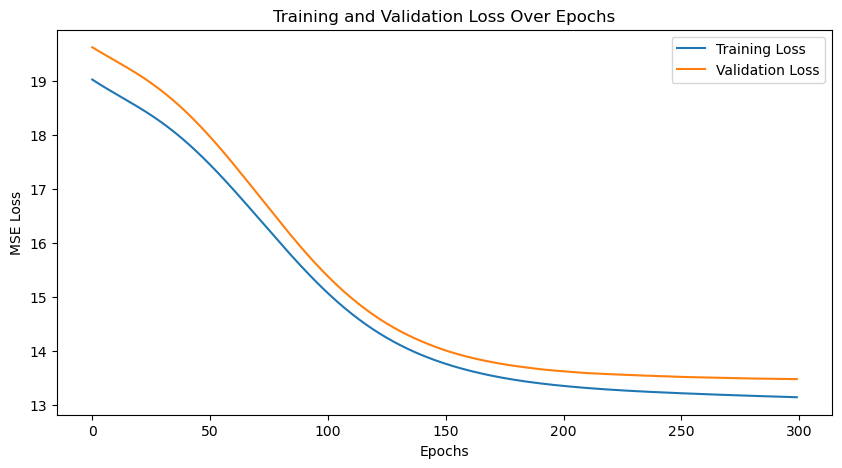

Validation Metrics - MSE: 13.4803, MAE: 2.8450, R2: 0.3119

Fold 13/20
Epoch 20/300 | Train Loss: 18.5471 | Val Loss: 18.3771
Epoch 40/300 | Train Loss: 17.8893 | Val Loss: 17.7483
Epoch 60/300 | Train Loss: 17.0743 | Val Loss: 16.9603
Epoch 80/300 | Train Loss: 16.1486 | Val Loss: 16.0790
Epoch 100/300 | Train Loss: 15.2631 | Val Loss: 15.2389
Epoch 120/300 | Train Loss: 14.5528 | Val Loss: 14.5734
Epoch 140/300 | Train Loss: 14.0548 | Val Loss: 14.1176
Epoch 160/300 | Train Loss: 13.7314 | Val Loss: 13.8325
Epoch 180/300 | Train Loss: 13.5261 | Val Loss: 13.6616
Epoch 200/300 | Train Loss: 13.4014 | Val Loss: 13.5629
Epoch 220/300 | Train Loss: 13.3239 | Val Loss: 13.5089
Epoch 240/300 | Train Loss: 13.2699 | Val Loss: 13.4789
Epoch 260/300 | Train Loss: 13.2302 | Val Loss: 13.4609
Epoch 280/300 | Train Loss: 13.1971 | Val Loss: 13.4484
Epoch 300/300 | Train Loss: 13.1689 | Val Loss: 13.4356


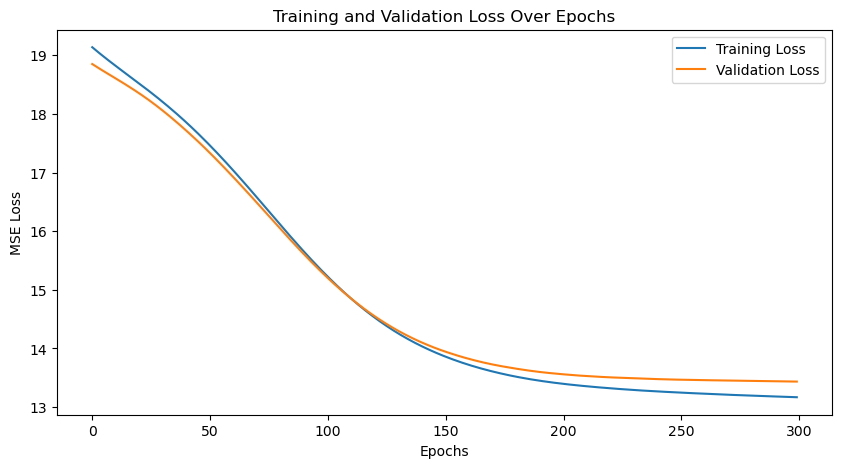

Validation Metrics - MSE: 13.4356, MAE: 2.8230, R2: 0.2852

Fold 14/20
Epoch 20/300 | Train Loss: 18.6174 | Val Loss: 17.8246
Epoch 40/300 | Train Loss: 17.9842 | Val Loss: 17.2280
Epoch 60/300 | Train Loss: 17.1324 | Val Loss: 16.4091
Epoch 80/300 | Train Loss: 16.1380 | Val Loss: 15.4775
Epoch 100/300 | Train Loss: 15.1902 | Val Loss: 14.6117
Epoch 120/300 | Train Loss: 14.4549 | Val Loss: 13.9567
Epoch 140/300 | Train Loss: 13.9724 | Val Loss: 13.5352
Epoch 160/300 | Train Loss: 13.6772 | Val Loss: 13.2754
Epoch 180/300 | Train Loss: 13.4986 | Val Loss: 13.1208
Epoch 200/300 | Train Loss: 13.3910 | Val Loss: 13.0415
Epoch 220/300 | Train Loss: 13.3230 | Val Loss: 12.9993
Epoch 240/300 | Train Loss: 13.2752 | Val Loss: 12.9800
Epoch 260/300 | Train Loss: 13.2382 | Val Loss: 12.9728
Epoch 280/300 | Train Loss: 13.2074 | Val Loss: 12.9723
Epoch 300/300 | Train Loss: 13.1808 | Val Loss: 12.9737


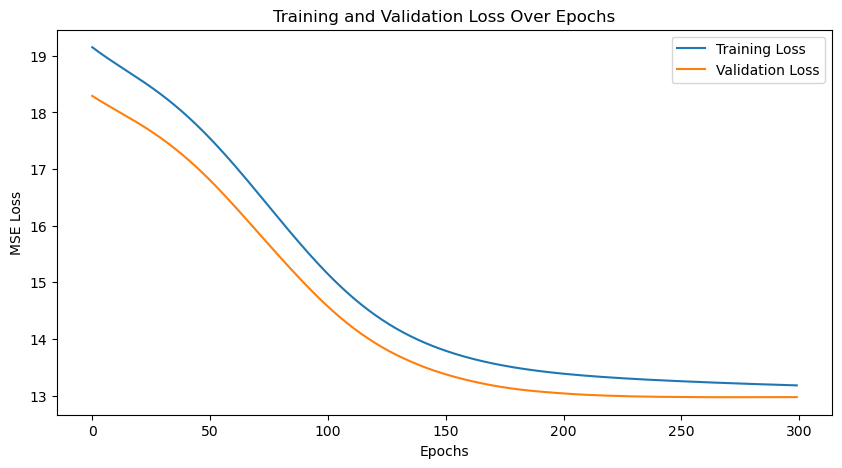

Validation Metrics - MSE: 12.9737, MAE: 2.7950, R2: 0.2875

Fold 15/20
Epoch 20/300 | Train Loss: 18.4287 | Val Loss: 19.0255
Epoch 40/300 | Train Loss: 17.7694 | Val Loss: 18.3487
Epoch 60/300 | Train Loss: 16.9428 | Val Loss: 17.4699
Epoch 80/300 | Train Loss: 16.0127 | Val Loss: 16.4754
Epoch 100/300 | Train Loss: 15.1273 | Val Loss: 15.5343
Epoch 120/300 | Train Loss: 14.4206 | Val Loss: 14.7911
Epoch 140/300 | Train Loss: 13.9518 | Val Loss: 14.2959
Epoch 160/300 | Train Loss: 13.6637 | Val Loss: 13.9836
Epoch 180/300 | Train Loss: 13.4817 | Val Loss: 13.7849
Epoch 200/300 | Train Loss: 13.3671 | Val Loss: 13.6600
Epoch 220/300 | Train Loss: 13.2930 | Val Loss: 13.5890
Epoch 240/300 | Train Loss: 13.2419 | Val Loss: 13.5465
Epoch 260/300 | Train Loss: 13.2025 | Val Loss: 13.5253
Epoch 280/300 | Train Loss: 13.1691 | Val Loss: 13.5040
Epoch 300/300 | Train Loss: 13.1407 | Val Loss: 13.4906


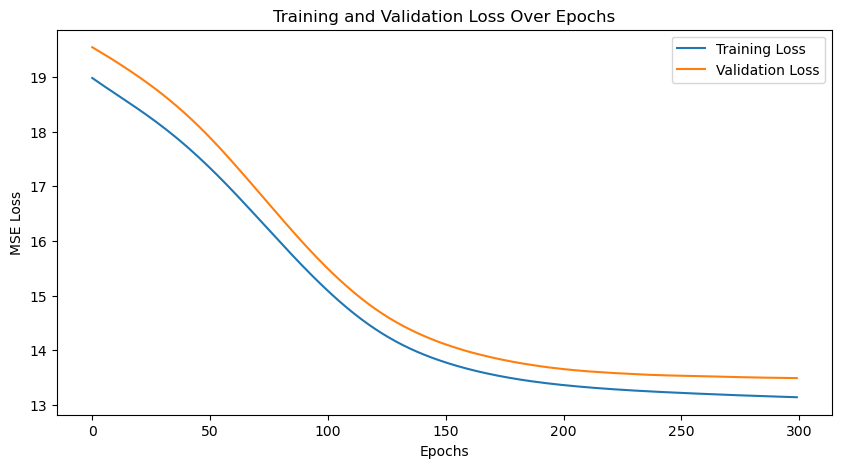

Validation Metrics - MSE: 13.4906, MAE: 2.8478, R2: 0.3102

Fold 16/20
Epoch 20/300 | Train Loss: 18.5732 | Val Loss: 18.6819
Epoch 40/300 | Train Loss: 17.9354 | Val Loss: 18.0658
Epoch 60/300 | Train Loss: 17.0939 | Val Loss: 17.2274
Epoch 80/300 | Train Loss: 16.1355 | Val Loss: 16.2808
Epoch 100/300 | Train Loss: 15.2289 | Val Loss: 15.3816
Epoch 120/300 | Train Loss: 14.5090 | Val Loss: 14.6838
Epoch 140/300 | Train Loss: 14.0154 | Val Loss: 14.2179
Epoch 160/300 | Train Loss: 13.6979 | Val Loss: 13.9287
Epoch 180/300 | Train Loss: 13.4963 | Val Loss: 13.7555
Epoch 200/300 | Train Loss: 13.3715 | Val Loss: 13.6617
Epoch 220/300 | Train Loss: 13.2918 | Val Loss: 13.6100
Epoch 240/300 | Train Loss: 13.2368 | Val Loss: 13.5814
Epoch 260/300 | Train Loss: 13.1964 | Val Loss: 13.5665
Epoch 280/300 | Train Loss: 13.1653 | Val Loss: 13.5565
Epoch 300/300 | Train Loss: 13.1392 | Val Loss: 13.5465


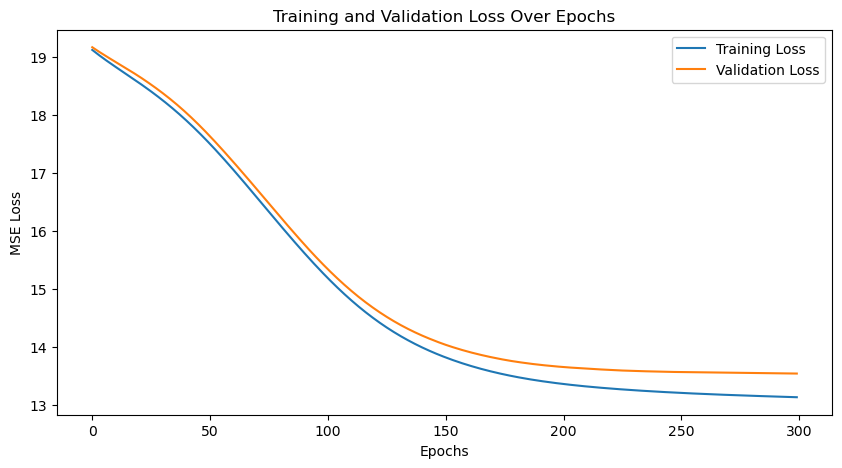

Validation Metrics - MSE: 13.5465, MAE: 2.8411, R2: 0.2895

Fold 17/20
Epoch 20/300 | Train Loss: 18.5212 | Val Loss: 17.8111
Epoch 40/300 | Train Loss: 17.8892 | Val Loss: 17.1500
Epoch 60/300 | Train Loss: 17.0142 | Val Loss: 16.2297
Epoch 80/300 | Train Loss: 16.0048 | Val Loss: 15.1705
Epoch 100/300 | Train Loss: 15.0690 | Val Loss: 14.1968
Epoch 120/300 | Train Loss: 14.3577 | Val Loss: 13.4740
Epoch 140/300 | Train Loss: 13.9032 | Val Loss: 13.0363
Epoch 160/300 | Train Loss: 13.6357 | Val Loss: 12.8111
Epoch 180/300 | Train Loss: 13.4784 | Val Loss: 12.7011
Epoch 200/300 | Train Loss: 13.3848 | Val Loss: 12.6551
Epoch 220/300 | Train Loss: 13.3259 | Val Loss: 12.6359
Epoch 240/300 | Train Loss: 13.2840 | Val Loss: 12.6328
Epoch 260/300 | Train Loss: 13.2499 | Val Loss: 12.6283
Epoch 280/300 | Train Loss: 13.2207 | Val Loss: 12.6286
Epoch 300/300 | Train Loss: 13.1950 | Val Loss: 12.6296


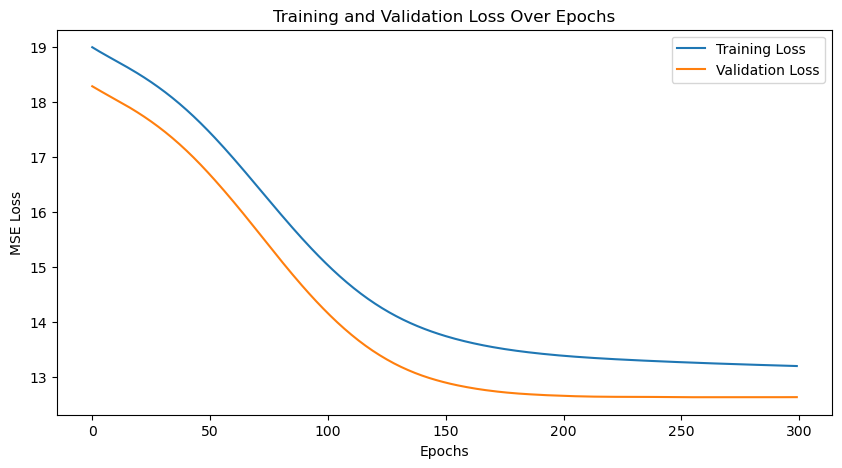

New best model found with MSE: 12.6296
Validation Metrics - MSE: 12.6296, MAE: 2.7661, R2: 0.3110

Fold 18/20
Epoch 20/300 | Train Loss: 18.5481 | Val Loss: 19.0046
Epoch 40/300 | Train Loss: 17.8949 | Val Loss: 18.3205
Epoch 60/300 | Train Loss: 17.0586 | Val Loss: 17.4395
Epoch 80/300 | Train Loss: 16.1287 | Val Loss: 16.4516
Epoch 100/300 | Train Loss: 15.2547 | Val Loss: 15.5224
Epoch 120/300 | Train Loss: 14.5360 | Val Loss: 14.7604
Epoch 140/300 | Train Loss: 14.0281 | Val Loss: 14.2363
Epoch 160/300 | Train Loss: 13.7112 | Val Loss: 13.9295
Epoch 180/300 | Train Loss: 13.5153 | Val Loss: 13.7649
Epoch 200/300 | Train Loss: 13.3929 | Val Loss: 13.6811
Epoch 220/300 | Train Loss: 13.3173 | Val Loss: 13.6319
Epoch 240/300 | Train Loss: 13.2662 | Val Loss: 13.6043
Epoch 260/300 | Train Loss: 13.2261 | Val Loss: 13.5803
Epoch 280/300 | Train Loss: 13.1917 | Val Loss: 13.5544
Epoch 300/300 | Train Loss: 13.1626 | Val Loss: 13.5310


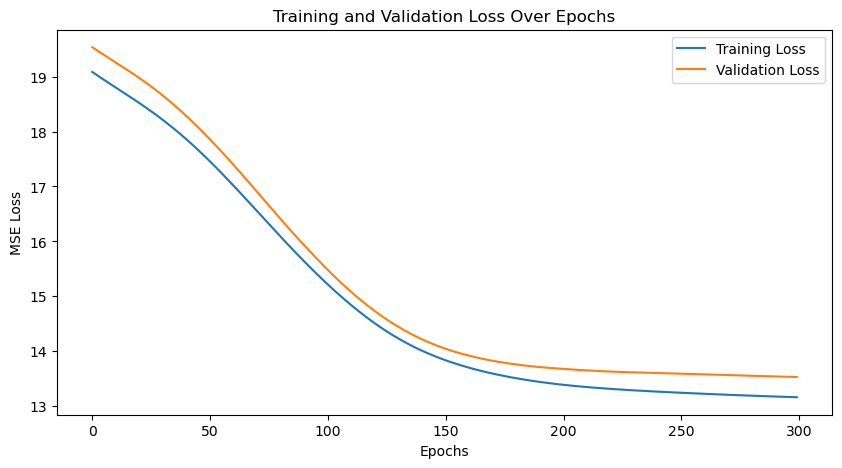

Validation Metrics - MSE: 13.5310, MAE: 2.8513, R2: 0.3037

Fold 19/20
Epoch 20/300 | Train Loss: 18.5065 | Val Loss: 18.3016
Epoch 40/300 | Train Loss: 17.8299 | Val Loss: 17.6308
Epoch 60/300 | Train Loss: 16.9227 | Val Loss: 16.7401
Epoch 80/300 | Train Loss: 15.9333 | Val Loss: 15.7674
Epoch 100/300 | Train Loss: 15.0520 | Val Loss: 14.9206
Epoch 120/300 | Train Loss: 14.3862 | Val Loss: 14.2957
Epoch 140/300 | Train Loss: 13.9441 | Val Loss: 13.8990
Epoch 160/300 | Train Loss: 13.6616 | Val Loss: 13.6636
Epoch 180/300 | Train Loss: 13.4803 | Val Loss: 13.5269
Epoch 200/300 | Train Loss: 13.3656 | Val Loss: 13.4555
Epoch 220/300 | Train Loss: 13.2912 | Val Loss: 13.4154
Epoch 240/300 | Train Loss: 13.2381 | Val Loss: 13.3879
Epoch 260/300 | Train Loss: 13.1967 | Val Loss: 13.3668
Epoch 280/300 | Train Loss: 13.1621 | Val Loss: 13.3465
Epoch 300/300 | Train Loss: 13.1330 | Val Loss: 13.3342


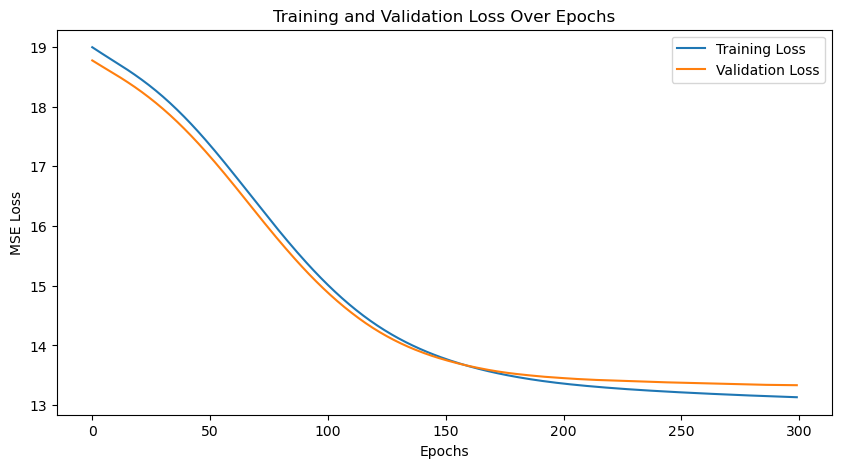

Validation Metrics - MSE: 13.3342, MAE: 2.8412, R2: 0.2888

Fold 20/20
Epoch 20/300 | Train Loss: 18.4471 | Val Loss: 18.6199
Epoch 40/300 | Train Loss: 17.7405 | Val Loss: 17.9051
Epoch 60/300 | Train Loss: 16.8310 | Val Loss: 16.9437
Epoch 80/300 | Train Loss: 15.8671 | Val Loss: 15.9026
Epoch 100/300 | Train Loss: 15.0129 | Val Loss: 14.9667
Epoch 120/300 | Train Loss: 14.3714 | Val Loss: 14.2539
Epoch 140/300 | Train Loss: 13.9518 | Val Loss: 13.7776
Epoch 160/300 | Train Loss: 13.6868 | Val Loss: 13.4763
Epoch 180/300 | Train Loss: 13.5130 | Val Loss: 13.2837
Epoch 200/300 | Train Loss: 13.3977 | Val Loss: 13.1654
Epoch 220/300 | Train Loss: 13.3183 | Val Loss: 13.0921
Epoch 240/300 | Train Loss: 13.2597 | Val Loss: 13.0459
Epoch 260/300 | Train Loss: 13.2167 | Val Loss: 13.0102
Epoch 280/300 | Train Loss: 13.1834 | Val Loss: 12.9858
Epoch 300/300 | Train Loss: 13.1545 | Val Loss: 12.9673


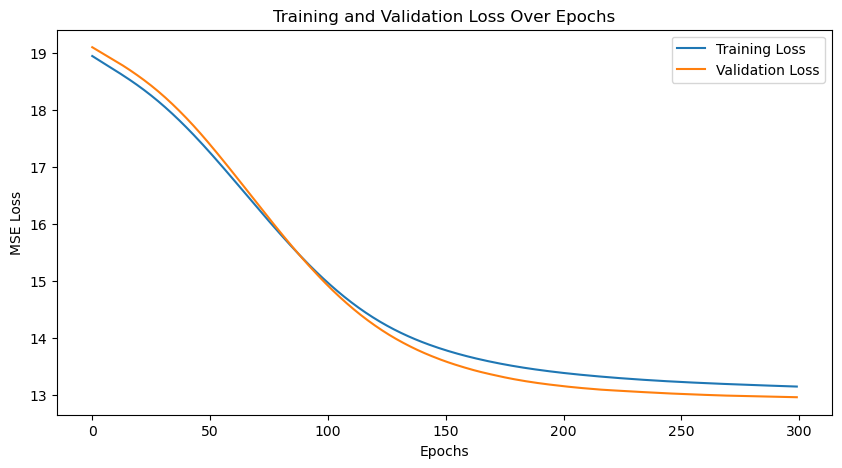

Validation Metrics - MSE: 12.9673, MAE: 2.7842, R2: 0.3236

Cross-Validation Summary:
Average MSE: 13.3466
Average MAE: 2.8295
Average R2: 0.2967
Best Model MSE: 12.6296


In [111]:
#Final Model
#DNN model 1, 300 epochs of training

# K-Fold Cross Validation on Training Data
print("\nRunning K-Fold Cross Validation:")
results = kfold_cross_validation(x_train, y_train, n_epochs = 300, model_num=1) #20 folds

Epoch 20/300 | Train Loss: 18.6899 | Val Loss: 18.6657
Epoch 40/300 | Train Loss: 18.0689 | Val Loss: 18.0569
Epoch 60/300 | Train Loss: 17.2353 | Val Loss: 17.2065
Epoch 80/300 | Train Loss: 16.2542 | Val Loss: 16.2152
Epoch 100/300 | Train Loss: 15.3161 | Val Loss: 15.2833
Epoch 120/300 | Train Loss: 14.5626 | Val Loss: 14.5538
Epoch 140/300 | Train Loss: 14.0454 | Val Loss: 14.0655
Epoch 160/300 | Train Loss: 13.7194 | Val Loss: 13.7636
Epoch 180/300 | Train Loss: 13.5166 | Val Loss: 13.5790
Epoch 200/300 | Train Loss: 13.3926 | Val Loss: 13.4674
Epoch 220/300 | Train Loss: 13.3157 | Val Loss: 13.4005
Epoch 240/300 | Train Loss: 13.2634 | Val Loss: 13.3576
Epoch 260/300 | Train Loss: 13.2250 | Val Loss: 13.3283
Epoch 280/300 | Train Loss: 13.1927 | Val Loss: 13.3086
Epoch 300/300 | Train Loss: 13.1646 | Val Loss: 13.2953


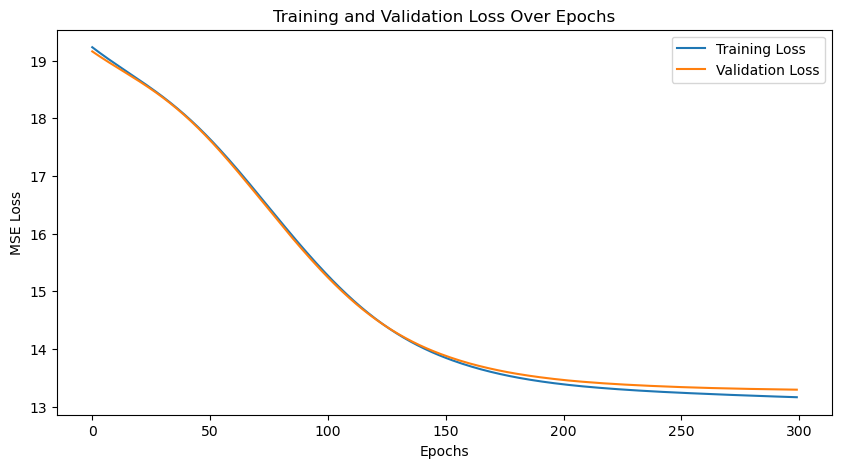


Evaluation Metrics:
MSE: 13.2953
MAE: 2.8151
R2 Score: 0.2989


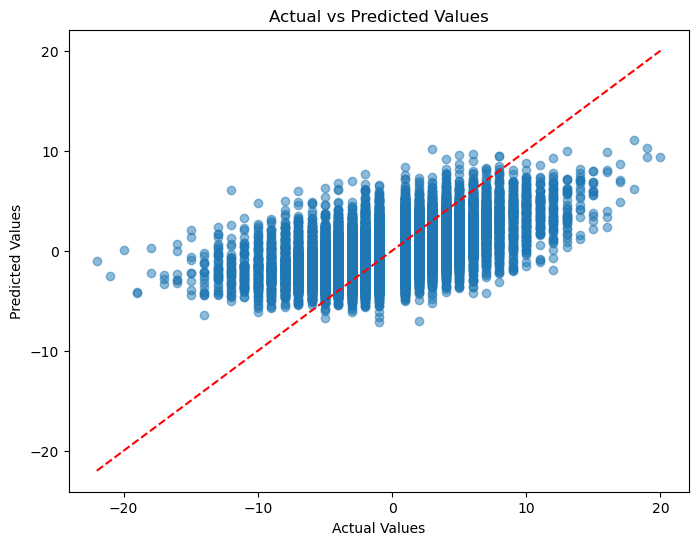

In [113]:
#Model 2 eval
model = train_model(x_train, y_train, x_test, y_test, n_epochs=300, model_num=1) 

evaluate_model(model, x_test, y_test) #model is retrained with complete training dataset for evaluation.
